## Dataset Column Descriptions (Numbered)

1. **`x`** – Longitude coordinate of the observation station.
2. **`y`** – Latitude coordinate of the observation station.
3. **`identifier`** – Unique record identifier combining instrument and metadata.
4. **`file_path`** – File path to the WOUDC archive where the record is stored.
5. **`dataset_id`** – Dataset type, e.g., "TotalOzone_1.0".
6. **`station_id`** – Numeric ID representing the station.
7. **`station_name`** – Name of the observation station.
8. **`station_gaw_id`** – Global Atmosphere Watch (GAW) ID for the station.
9. **`station_gaw_url`** – URL to the station’s GAWSIS information page.
10. **`contributor_name`** – Name of the organization that submitted the data.
11. **`contributor_id`** – ID of the contributing organization.
12. **`contributor_url`** – URL for the contributor's organization or data page.
13. **`country_id`** – Country code (e.g., "BRA" for Brazil).
14. **`country_name_en`** – Country name in English.
15. **`country_name_fr`** – Country name in French.
16. **`gaw_id`** – Unique GAWSIS identifier for the observation site.
17. **`instrument_name`** – Type or name of the ozone measuring instrument.
18. **`instrument_model`** – Specific model of the instrument.
19. **`instrument_serial`** – Serial number of the instrument.
20. **`observation_date`** – Timestamp of the measurement.
21. **`daily_date`** – Date of the daily ozone observation.
22. **`daily_wlcode`** – Wavelength code used in observation.
23. **`daily_obscode`** – Code indicating observation method or quality.
24. **`daily_columno3`** – Daily total column ozone in Dobson Units (DU).
25. **`daily_stdevo3`** – Standard deviation of the ozone measurements.
26. **`daily_utc_begin`** – UTC time when the first observation began.
27. **`daily_utc_end`** – UTC time when the last observation ended.
28. **`daily_utc_mean`** – Mean UTC time of the day’s observations.
29. **`daily_nobs`** – Number of ozone observations taken in the day.
30. **`daily_mmu`** – Measurement uncertainty of daily ozone data.
31. **`daily_columnso2`** – Measured sulfur dioxide (SO₂) column (if available).
32. **`monthly_date`** – Date representing the month of the aggregated record.
33. **`monthly_columno3`** – Monthly average ozone column value.
34. **`monthly_stdevo3`** – Standard deviation of the monthly ozone.
35. **`monthly_npts`** – Number of measurements used to calculate the monthly average.
36. **`url`** – Direct link to the source data file on the WOUDC server.


**Combining  8 Countries Datasets**
<br>
<ol>
<li>Argentina</li>
<li>Brazil</li>
<li>Canada</li>
<li>Chile</li>
<li>Greenland</li>
<li>Mexico</li>
<li>Peru</li>
<li>USA</li>
</ol>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import optuna
from optuna.samplers import TPESampler
import plotly.express as px
import plotly.graph_objects as go


c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df1=pd.read_csv('combined_dataset/totalozone_ARG.csv')
df2=pd.read_csv('combined_dataset/totalozone_BRA.csv')
df3=pd.read_csv('combined_dataset/totalozone_CAN.csv')
df4=pd.read_csv('combined_dataset/totalozone_CHL.csv')
df5=pd.read_csv('combined_dataset/totalozone_GRL.csv')
df6=pd.read_csv('combined_dataset/totalozone_MEX.csv')
df7=pd.read_csv('combined_dataset/totalozone_PER.csv')
df8=pd.read_csv('combined_dataset/totalozone_USA.csv')
df=pd.concat([df1, df2, df3, df4, df5, df6, df7, df8], ignore_index=True)
df['daily_date'] = pd.to_datetime(df['daily_date'], format='%Y-%m-%d')
df.head()






c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (21,26) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (22,25,26,27) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns (22) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)
c:\Users\Abir Hossain\AppData\Local\Programs\Python\Python37\lib\site-packages\IPython\core\interactiveshell.py:3258: DtypeWarning: Columns

,x,y,identifier,file_path,dataset_id,station_id,station_name,station_gaw_id,station_gaw_url,contributor_name,...,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,monthly_date,monthly_columno3,monthly_stdevo3,monthly_npts,url
0,-58.480,-34.580,Dobson:Beck:70:TotalOzone_1.0:091:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,91,Buenos Aires Observatorio,BSO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,6.0,1.800,NaN,2025-04-30T00:00:00Z,277.2,13.9,29.0,https://woudc.org/archive/Archive-NewFormat/To...
1,-68.310,-54.850,Dobson:Beck:131:TotalOzone_1.0:339:SMNA:WOUDC:...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,339,Ushuaia,USH,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,17.5,17.5,1.0,2.976,NaN,2025-04-30T00:00:00Z,277.0,27.7,30.0,https://woudc.org/archive/Archive-NewFormat/To...
2,-67.500,-45.783,Dobson:Beck:133:TotalOzone_1.0:342:SMNA:WOUDC:...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,342,Comodoro Rivadavia Aero,CMR,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,16.0,NaN,8.0,2.300,NaN,2025-04-30T00:00:00Z,263.4,21.7,28.0,https://woudc.org/archive/Archive-NewFormat/To...
3,-65.438,-22.111,Dobson:Beck:97:TotalOzone_1.0:513:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,513,La Quiaca,LQO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,3.0,1.500,NaN,2025-04-30T00:00:00Z,254.1,3.5,25.0,https://woudc.org/archive/Archive-NewFormat/To...
4,-58.480,-34.580,Dobson:Beck:70:TotalOzone_1.0:091:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,91,Buenos Aires Observatorio,BSO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,6.0,1.700,NaN,2025-04-30T00:00:00Z,277.2,13.9,29.0,https://woudc.org/archive/Archive-NewFormat/To...


<h2>Visualization</h2>

**Area Chart of Year Vs Ozone**

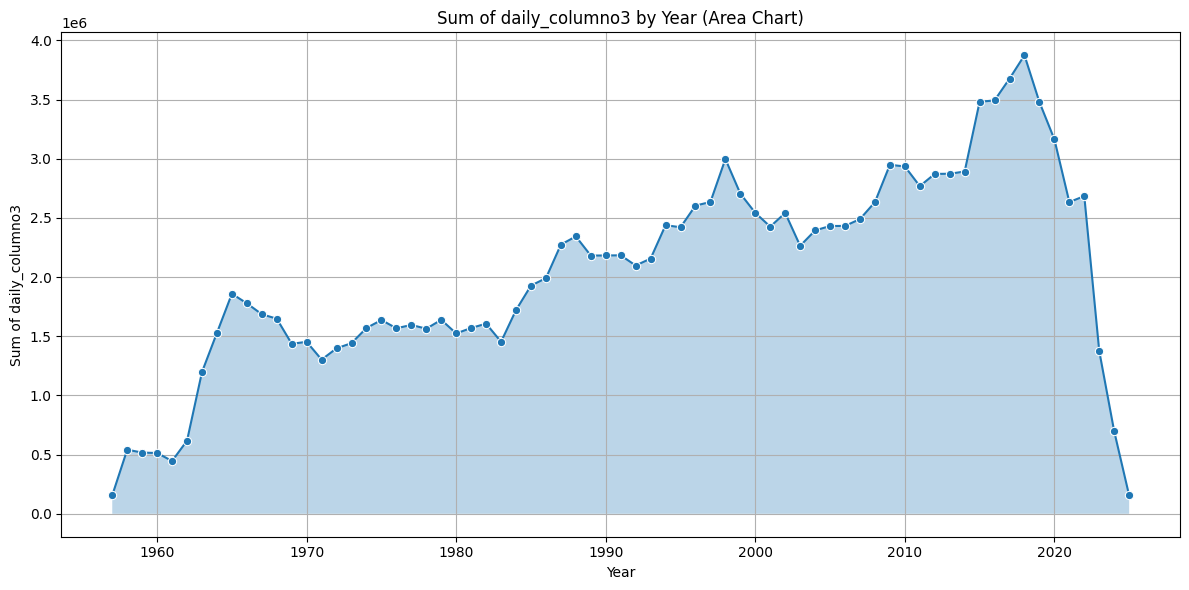

In [204]:
df['year'] = pd.to_numeric(df['daily_date'].dt.year, errors='coerce')

plt.figure(figsize=(12, 6))
df_yearly = df.groupby('year')['daily_columno3'].sum().reset_index()
sns.lineplot(data=df_yearly, x='year', y='daily_columno3', marker='o')
plt.fill_between(df_yearly['year'], df_yearly['daily_columno3'], alpha=0.3)
plt.title('Sum of daily_columno3 by Year (Area Chart)')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()


**Bar Chart of Year Vs Ozone (After and Before 1989)**

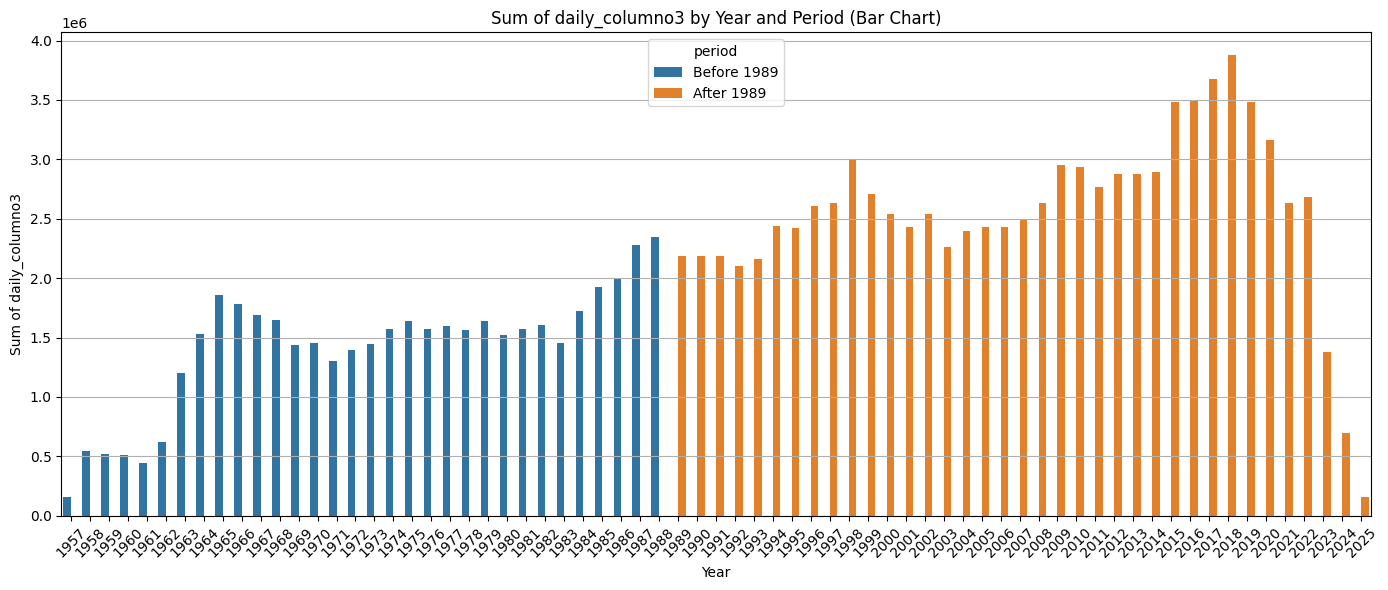

In [205]:
df['period'] = df['year'].apply(lambda x: 'Before 1989' if x < 1989 else 'After 1989')

# Group by year and period
df_period = df.groupby(['year', 'period'])['daily_columno3'].sum().reset_index()

# Plot bar chart
plt.figure(figsize=(14, 6))
sns.barplot(data=df_period, x='year', y='daily_columno3', hue='period', dodge=True)

plt.title('Sum of daily_columno3 by Year and Period (Bar Chart)')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

**Bar Chart of Year Vs Ozone**

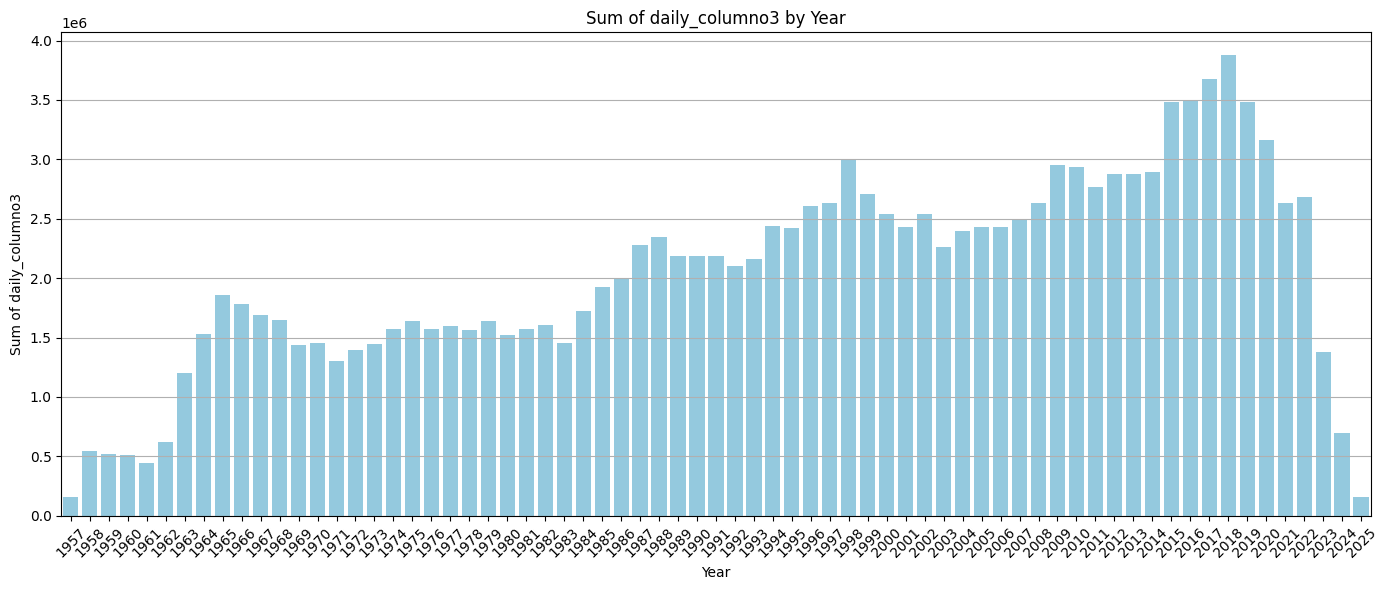

In [206]:
df_yearly = df.groupby('year')['daily_columno3'].sum().reset_index()

# Plot bar chart
plt.figure(figsize=(14, 6))
sns.barplot(data=df_yearly, x='year', y='daily_columno3', color='skyblue')

plt.title('Sum of daily_columno3 by Year')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

**Line chart Year vs ozone (before and after 1989)**

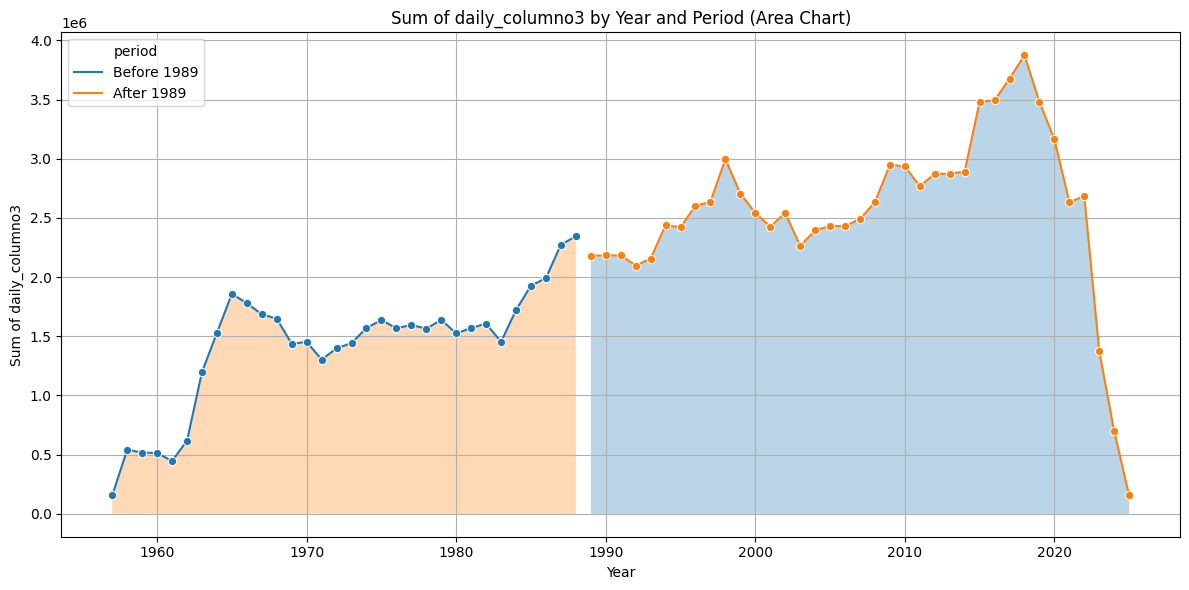

In [207]:
df['period'] = df['year'].apply(lambda x: 'Before 1989' if x < 1989 else 'After 1989')
plt.figure(figsize=(12, 6))
df_period = df.groupby(['year', 'period'])['daily_columno3'].sum().reset_index()
sns.lineplot(data=df_period, x='year', y='daily_columno3', hue='period', marker='o')
for period, group in df_period.groupby('period'):
    plt.fill_between(group['year'], group['daily_columno3'], alpha=0.3, label=f"{period} (area)")
plt.title('Sum of daily_columno3 by Year and Period (Area Chart)')
plt.ylabel('Sum of daily_columno3')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()


**Country wise year vs ozone**

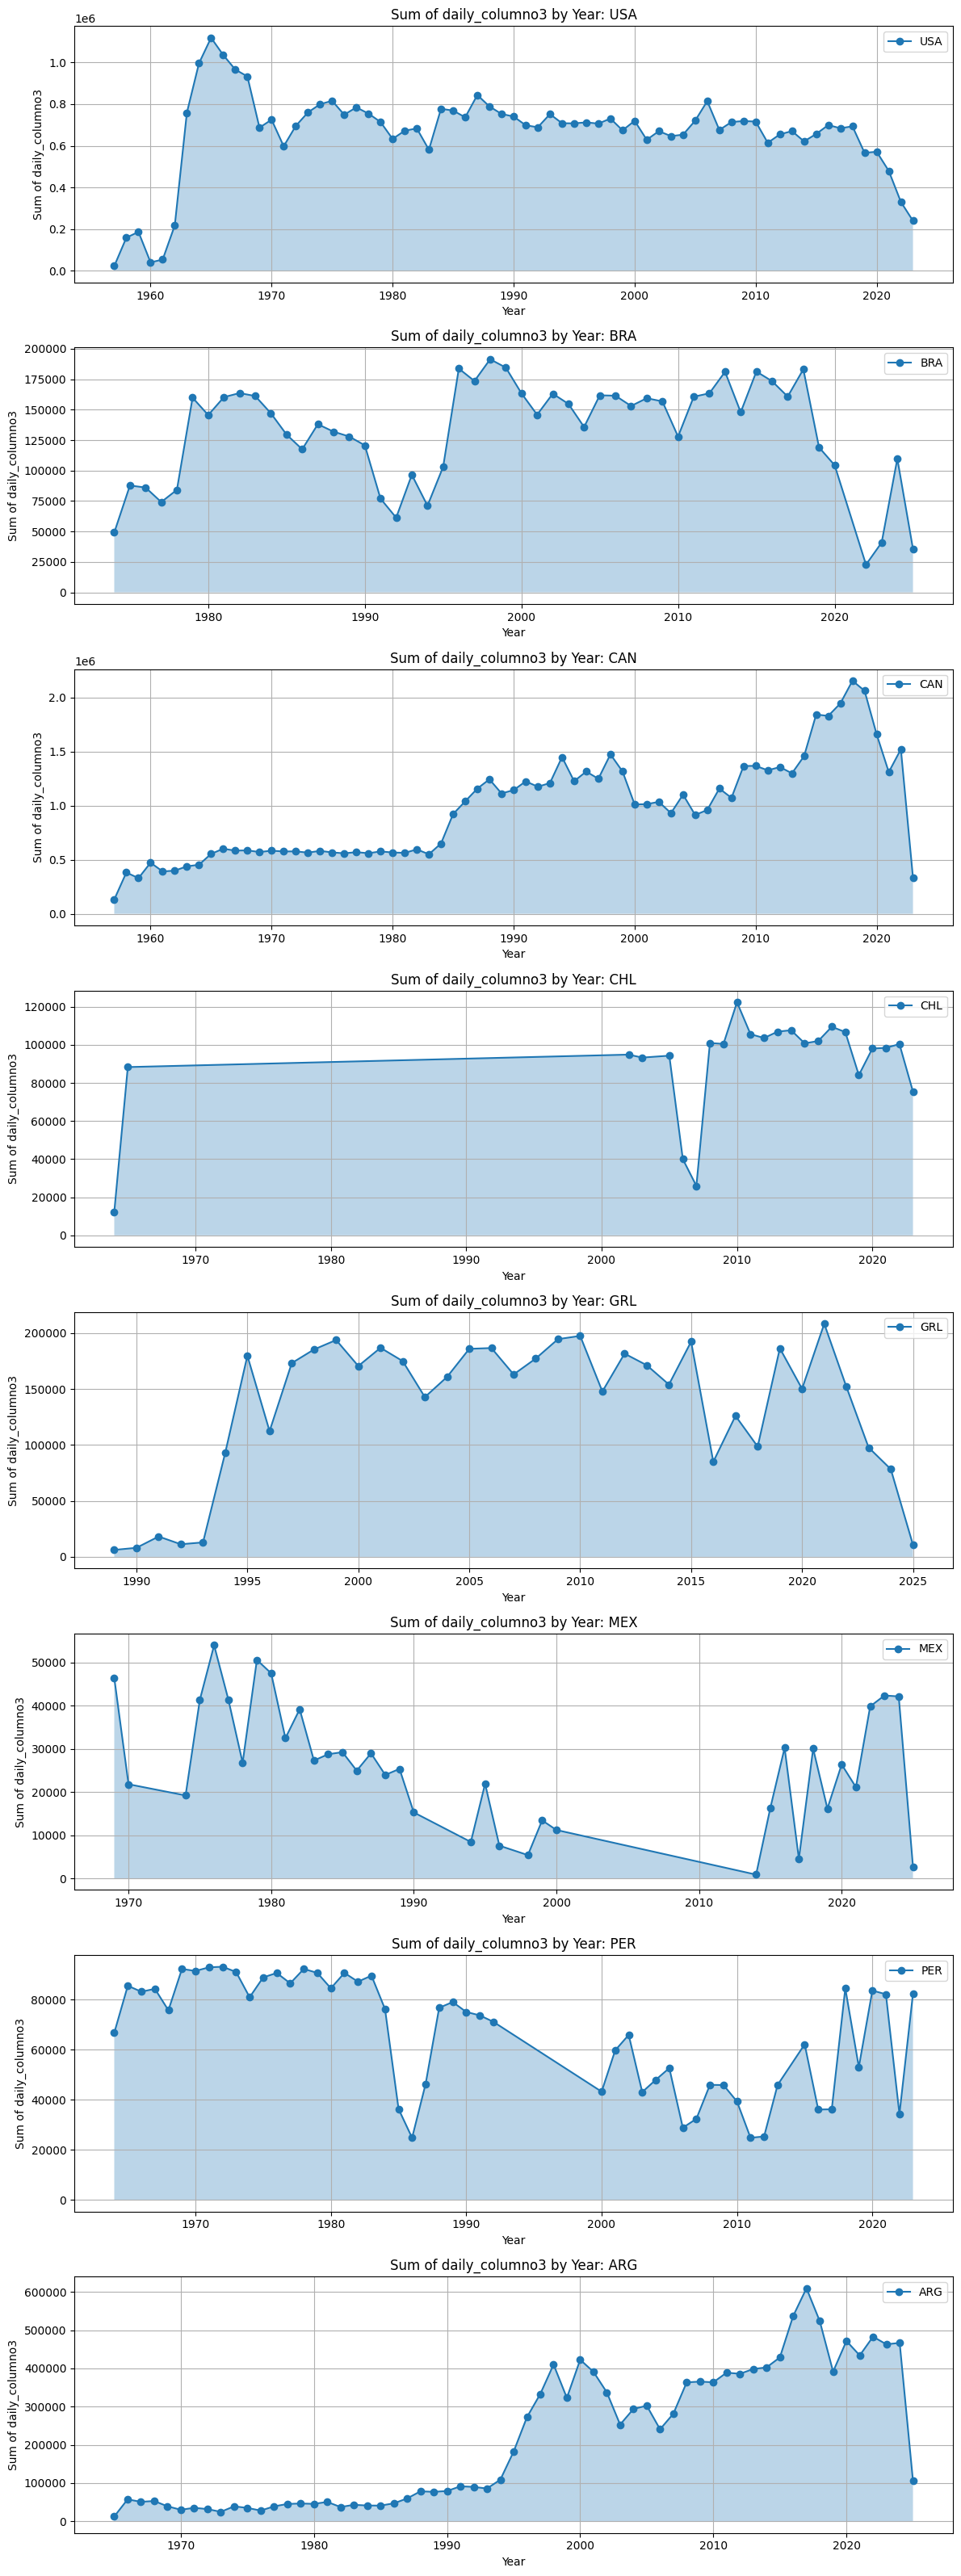

In [208]:
countries = ['USA', 'BRA', 'CAN', 'CHL', 'GRL', 'MEX', 'PER','ARG']
6
plt.figure(figsize=(12,4 * len(countries)))
for idx, country in enumerate(countries, 1):
    plt.subplot(len(countries), 1, idx)
    df_country = df[df['country_id'] == country]
    df_yearly = df_country.groupby('year')['daily_columno3'].sum().reset_index()
    plt.plot(df_yearly['year'], df_yearly['daily_columno3'], marker='o', label=country)
    plt.fill_between(df_yearly['year'], df_yearly['daily_columno3'], alpha=0.3)
    plt.title(f'Sum of daily_columno3 by Year: {country}')
    plt.ylabel('Sum of daily_columno3')
    plt.xlabel('Year')
    plt.grid(True)
    plt.legend()
plt.tight_layout()
plt.show()


***<h1>Specific Country wise model check</h1>***

In [4]:
usa_df = df8.copy()
can_df =df3.copy()
bra_df = df2.copy()
arg_df = df1.copy()
chl_df =df4.copy()
grl_df = df5.copy()
mex_df = df6.copy()
per_df = df7.copy()
print("Shape of DataFrames for each country:")
print(usa_df.shape)
print(can_df.shape)
print(bra_df.shape)
print(arg_df.shape)
print(chl_df.shape)
print(grl_df.shape)
print(mex_df.shape)
print(per_df.shape)


Shape of DataFrames for each country:
(140695, 36)
(187033, 36)
(24865, 36)
(45720, 36)
(6898, 36)
(14498, 36)
(3615, 36)
(13811, 36)


In [5]:
# Loop through each dataset
country_dfs = {
    'USA': usa_df,
    'CAN': can_df,
    'BRA': bra_df,
    'ARG': arg_df,
    'CHL': chl_df,
    'GRL': grl_df,
    'MEX': mex_df,
    'PER': per_df
}

for name, df in country_dfs.items():
    print(f"\n📊 Checking dataset: {name}")
    print("=" * 40)

    # Missing Values
    print("🔍 Missing Values:")
    print(df.isnull().sum())
    print("\n📉 Percentage of Missing Values:")
    print((df.isnull().sum() / df.shape[0] * 100).round(2))
    print("*" * 30)

    # Duplicates
    print(f"🧩 Duplicates: {df.duplicated().sum()}")
    print("*" * 30)

    # Garbage Values in object columns
    object_cols = df.select_dtypes(include='object').columns
    if len(object_cols) > 0:
        print("🗑️ Garbage (Unexpected) Values in Object Columns:")
        for col in object_cols:
            print(f"\n🔸 Column: {col}")
            print(df[col].value_counts(dropna=False))
    else:
        print("✅ No object (text) columns to check for garbage.")
    
    print("=" * 40)



📊 Checking dataset: USA
🔍 Missing Values:
x                         0
y                         0
identifier                0
file_path                 0
dataset_id                0
station_id                0
station_name              0
station_gaw_id            0
station_gaw_url           0
contributor_name          0
contributor_id            0
contributor_url       19372
country_id                0
country_name_en           0
country_name_fr           0
gaw_id               140695
instrument_name           0
instrument_model          0
instrument_serial         0
observation_date          0
daily_date                0
daily_wlcode              0
daily_obscode             0
daily_columno3            0
daily_stdevo3        132764
daily_utc_begin      133339
daily_utc_end        133309
daily_utc_mean           89
daily_nobs           132764
daily_mmu            132764
daily_columnso2      132764
monthly_date            220
monthly_columno3        220
monthly_stdevo3         220
month

**Data Pre-Processing**

*Dropping Null Values*

In [6]:
columns = [
    'x',
    'y',
    'identifier',
    'file_path',
    'dataset_id',
    'station_id',
    'station_name',
    'station_gaw_id',
    'station_gaw_url',
    'contributor_name',
    'contributor_id',
    'contributor_url',
    'country_id',
    'country_name_en',
    'country_name_fr',
    'gaw_id',
    'instrument_name',
    'instrument_model',
    'instrument_serial',
    'observation_date',
    'daily_wlcode',
    'daily_obscode',
    'daily_stdevo3',
    'daily_utc_begin',
    'daily_utc_end',
    'daily_utc_mean',
    'daily_nobs',
    'daily_mmu',
    'daily_columnso2',
    'monthly_date',
    'monthly_columno3',
    'monthly_stdevo3',
    'monthly_npts',
    'url'
]
usa_df.drop(columns=columns, inplace=True)
can_df.drop(columns=columns, inplace=True)
bra_df.drop(columns=columns, inplace=True)
arg_df.drop(columns=columns, inplace=True)
chl_df.drop(columns=columns, inplace=True)
grl_df.drop(columns=columns, inplace=True)
mex_df.drop(columns=columns, inplace=True)
per_df.drop(columns=columns, inplace=True)

*GroupingBy Data's Based on daily_date and droping null rows* 

In [7]:
usa_df = usa_df.groupby('daily_date').mean(numeric_only=True).reset_index()
usa_df = usa_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
usa_df.dropna(subset=['daily_columno3'], inplace=True)

can_df = can_df.groupby('daily_date').mean(numeric_only=True).reset_index()
can_df = can_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
can_df.dropna(subset=['daily_columno3'], inplace=True)

bra_df = bra_df.groupby('daily_date').mean(numeric_only=True).reset_index()
bra_df = bra_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
bra_df.dropna(subset=['daily_columno3'], inplace=True)

arg_df = arg_df.groupby('daily_date').mean(numeric_only=True).reset_index()
arg_df = arg_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
arg_df.dropna(subset=['daily_columno3'], inplace=True)

chl_df = chl_df.groupby('daily_date').mean(numeric_only=True).reset_index()
chl_df = chl_df.sort_values('daily_date', ascending=True).reset_index(drop=True)    
chl_df.dropna(subset=['daily_columno3'], inplace=True)

grl_df = grl_df.groupby('daily_date').mean(numeric_only=True).reset_index()
grl_df = grl_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
grl_df.dropna(subset=['daily_columno3'], inplace=True)

mex_df = mex_df.groupby('daily_date').mean(numeric_only=True).reset_index()
mex_df = mex_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
mex_df.dropna(subset=['daily_columno3'], inplace=True)

per_df = per_df.groupby('daily_date').mean(numeric_only=True).reset_index()
per_df = per_df.sort_values('daily_date', ascending=True).reset_index(drop=True)
per_df.dropna(subset=['daily_columno3'], inplace=True)

**Checking Outliers of several Datasets**


📦 Outlier detection for: USA


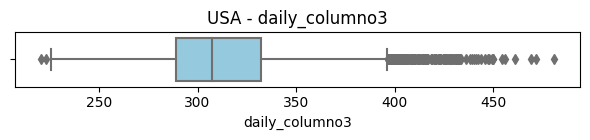


📦 Outlier detection for: CAN


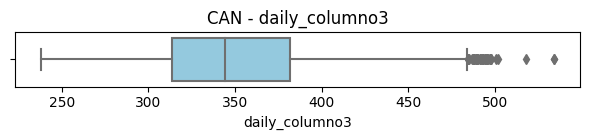


📦 Outlier detection for: BRA


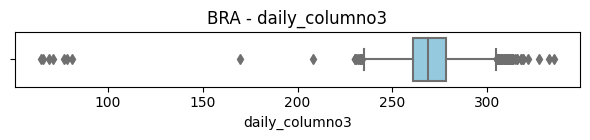


📦 Outlier detection for: ARG


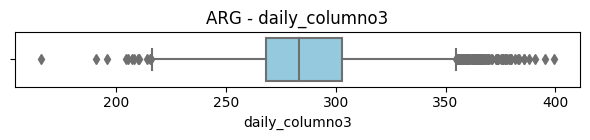


📦 Outlier detection for: CHL


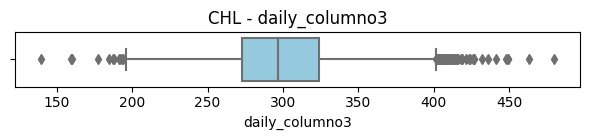


📦 Outlier detection for: GRL


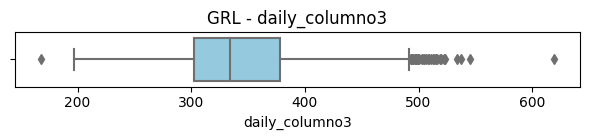


📦 Outlier detection for: MEX


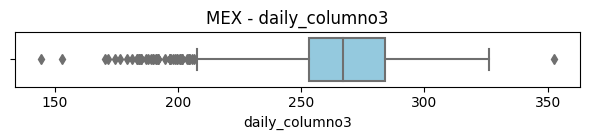


📦 Outlier detection for: PER


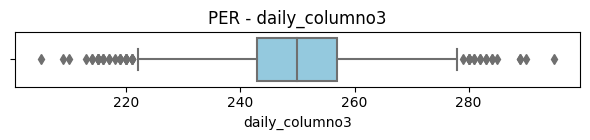

In [8]:
country_dfs = {
    'USA': usa_df,
    'CAN': can_df,
    'BRA': bra_df,
    'ARG': arg_df,
    'CHL': chl_df,
    'GRL': grl_df,
    'MEX': mex_df,
    'PER': per_df
}

# Loop through each DataFrame
for country, df in country_dfs.items():
    print(f"\n📦 Outlier detection for: {country}")
    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        plt.figure(figsize=(6, 1.5))
        sns.boxplot(data=df, x=col, color="skyblue")
        plt.title(f"{country} - {col}")
        plt.tight_layout()
        plt.show()

In [9]:


# Dictionary of country DataFrames
country_dfs = {
    'USA': usa_df,
    'CAN': can_df,
    'BRA': bra_df,
    'ARG': arg_df,
    'CHL': chl_df,
    'GRL': grl_df,
    'MEX': mex_df,
    'PER': per_df
}

# Function to calculate whiskers
def calculate_whiskers(col):
    q1, q3 = np.percentile(col.dropna(), [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

# Outlier treatment: clip to whisker bounds
for name, df in country_dfs.items():
    print(f"\n🛠️ Treating outliers for: {name}")
    numeric_cols = df.select_dtypes(include='number').columns

    for col in numeric_cols:
        lower, upper = calculate_whiskers(df[col])
        original_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        print(f"   - {col}: {original_outliers} outliers clipped")

        # Clip values to lower and upper bounds
        df[col] = df[col].clip(lower=lower, upper=upper)

    # Replace in the dictionary
    country_dfs[name] = df



🛠️ Treating outliers for: USA
   - daily_columno3: 197 outliers clipped

🛠️ Treating outliers for: CAN
   - daily_columno3: 42 outliers clipped

🛠️ Treating outliers for: BRA
   - daily_columno3: 102 outliers clipped

🛠️ Treating outliers for: ARG
   - daily_columno3: 145 outliers clipped

🛠️ Treating outliers for: CHL
   - daily_columno3: 74 outliers clipped

🛠️ Treating outliers for: GRL
   - daily_columno3: 39 outliers clipped

🛠️ Treating outliers for: MEX
   - daily_columno3: 51 outliers clipped

🛠️ Treating outliers for: PER
   - daily_columno3: 47 outliers clipped


In [10]:
# Loop through each dataset
for name, df in country_dfs.items():
    print(f"\n📊 Checking dataset: {name}")
    print("=" * 40)

    # Missing Values
    print("🔍 Missing Values:")
    print(df.isnull().sum())
    print("\n📉 Percentage of Missing Values:")
    print((df.isnull().sum() / df.shape[0] * 100).round(2))
    print("*" * 30)

    # Duplicates
    print(f"🧩 Duplicates: {df.duplicated().sum()}")
    print("*" * 30)

    # Garbage Values in object columns
    object_cols = df.select_dtypes(include='object').columns
    if len(object_cols) > 0:
        print("🗑️ Garbage (Unexpected) Values in Object Columns:")
        for col in object_cols:
            print(f"\n🔸 Column: {col}")
            print(df[col].value_counts(dropna=False))
    else:
        print("✅ No object (text) columns to check for garbage.")
    
    print("=" * 40)



📊 Checking dataset: USA
🔍 Missing Values:
daily_date        0
daily_columno3    0
dtype: int64

📉 Percentage of Missing Values:
daily_date        0.0
daily_columno3    0.0
dtype: float64
******************************
🧩 Duplicates: 0
******************************
🗑️ Garbage (Unexpected) Values in Object Columns:

🔸 Column: daily_date
1977-05-20T00:00:00Z    1
2000-04-24T00:00:00Z    1
1976-10-08T00:00:00Z    1
2004-09-25T00:00:00Z    1
1990-04-10T00:00:00Z    1
                       ..
2002-11-02T00:00:00Z    1
1997-07-10T00:00:00Z    1
1988-02-02T00:00:00Z    1
1980-07-26T00:00:00Z    1
1966-01-06T00:00:00Z    1
Name: daily_date, Length: 23639, dtype: int64

📊 Checking dataset: CAN
🔍 Missing Values:
daily_date        0
daily_columno3    0
dtype: int64

📉 Percentage of Missing Values:
daily_date        0.0
daily_columno3    0.0
dtype: float64
******************************
🧩 Duplicates: 0
******************************
🗑️ Garbage (Unexpected) Values in Object Columns:

🔸 Column: dai

**Checking For Outliers Again**


📦 Outlier detection for: USA


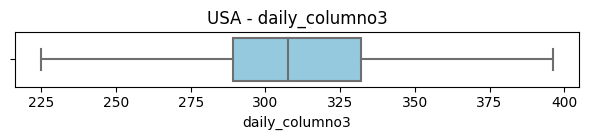


📦 Outlier detection for: CAN


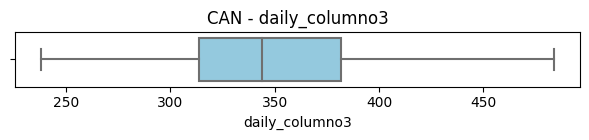


📦 Outlier detection for: BRA


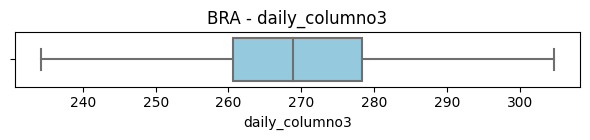


📦 Outlier detection for: ARG


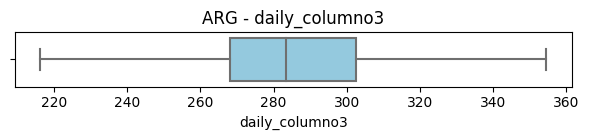


📦 Outlier detection for: CHL


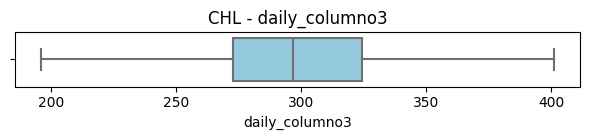


📦 Outlier detection for: GRL


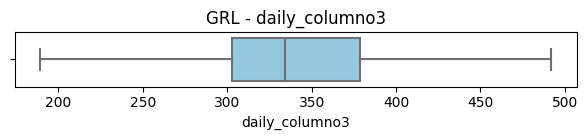


📦 Outlier detection for: MEX


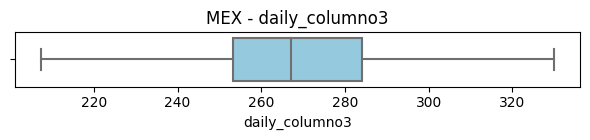


📦 Outlier detection for: PER


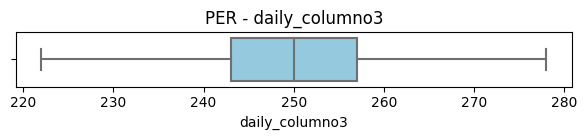

In [11]:
country_dfs = {
    'USA': usa_df,
    'CAN': can_df,
    'BRA': bra_df,
    'ARG': arg_df,
    'CHL': chl_df,
    'GRL': grl_df,
    'MEX': mex_df,
    'PER': per_df
}

# Loop through each DataFrame
for country, df in country_dfs.items():
    print(f"\n📦 Outlier detection for: {country}")
    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        plt.figure(figsize=(6, 1.5))
        sns.boxplot(data=df, x=col, color="skyblue")
        plt.title(f"{country} - {col}")
        plt.tight_layout()
        plt.show()

*Creating Lag Features of 15 days, Rolling Average of past 10 days, Exponential Average of past 10 days,Rolling Standard Deviation of past 10 days,Exponential Standard Deviation of past 10 days*

In [12]:

usa_df['rolling_avg'] = usa_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
usa_df['rolling_std'] = usa_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
usa_df['ewm_avg'] = usa_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
usa_df['ewm_std'] = usa_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
  usa_df[f'lag{i}'] = usa_df['daily_columno3'].shift(i)

usa_df.dropna(inplace=True)

can_df['rolling_avg'] = can_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
can_df['rolling_std'] = can_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
can_df['ewm_avg'] = can_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
can_df['ewm_std'] = can_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    can_df[f'lag{i}'] = can_df['daily_columno3'].shift(i)
can_df.dropna(inplace=True)


bra_df['rolling_avg'] = bra_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
bra_df['rolling_std'] = bra_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
bra_df['ewm_avg'] = bra_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
bra_df['ewm_std'] = bra_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    bra_df[f'lag{i}'] = bra_df['daily_columno3'].shift(i)
bra_df.dropna(inplace=True)


arg_df['rolling_avg'] = arg_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
arg_df['rolling_std'] = arg_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
arg_df['ewm_avg'] = arg_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
arg_df['ewm_std'] = arg_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    arg_df[f'lag{i}'] = arg_df['daily_columno3'].shift(i)
arg_df.dropna(inplace=True)


chl_df['rolling_avg'] = chl_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
chl_df['rolling_std'] = chl_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
chl_df['ewm_avg'] = chl_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()

chl_df['ewm_std'] = chl_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    chl_df[f'lag{i}'] = chl_df['daily_columno3'].shift(i)
chl_df.dropna(inplace=True)


chl_df.head()
grl_df['rolling_avg'] = grl_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
grl_df['rolling_std'] = grl_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
grl_df['ewm_avg'] = grl_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
grl_df['ewm_std'] = grl_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    grl_df[f'lag{i}'] = grl_df['daily_columno3'].shift(i)
grl_df.dropna(inplace=True)


mex_df['rolling_avg'] = mex_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
mex_df['rolling_std'] = mex_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
mex_df['ewm_avg'] = mex_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
mex_df['ewm_std'] = mex_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    mex_df[f'lag{i}'] = mex_df['daily_columno3'].shift(i)
mex_df.dropna(inplace=True)

per_df['rolling_avg'] = per_df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
per_df['rolling_std'] = per_df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
per_df['ewm_avg'] = per_df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
per_df['ewm_std'] = per_df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
    per_df[f'lag{i}'] = per_df['daily_columno3'].shift(i)
per_df.dropna(inplace=True)

In [14]:
country_cfs = {
    'USA': usa_df,
    'CAN': can_df,
    'BRA': bra_df,
    'ARG': arg_df,
    'CHL': chl_df,
    'GRL': grl_df,
    'MEX': mex_df,
    'PER': per_df
}

# Define features to use in the model
features = ['rolling_avg', 'rolling_std', 'ewm_avg', 'ewm_std'] + [f'lag{i}' for i in range(1, 16)]

# Define models
models = {
   'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(),
    'AdaBoost Regressor': AdaBoostRegressor(n_estimators=50, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42),
    'K-Neighbors Regressor': KNeighborsRegressor(n_neighbors=3)
}

# Store results
eval_results = []

for country, cf in country_cfs.items():
    print(f"\n🌍 Running models for: {country}")

    # Prepare data
    X = cf[features]
    y = cf['daily_columno3']

    # Scale features
    scaler_x= MinMaxScaler()
    scaler_y= MinMaxScaler()
    

    # Split
    split_index = int(len(X) * 0.8)
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

    # Scale the data
    X_train = scaler_x.fit_transform(X_train)
    X_test = scaler_x.transform(X_test)
    y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

    for model_name, model in models.items():
        print(f"   🔧 Training: {model_name}")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Evaluation
        rmse = mean_squared_error(y_test, y_pred, squared=False)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        # Save to results
        eval_results.append({
            'Country': country,
            'Model': model_name,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2 * 100
        })
        print()

# Convert results to DataFrame
results_df = pd.DataFrame(eval_results).sort_values(['Country', 'RMSE'])
print("\n📊 Evaluation Summary (sorted by country and RMSE):")
for country in results_df['Country'].unique():
    print(f"\nResults for {country}:")
    country_results = results_df[results_df['Country'] == country]
    print(country_results[['Model', 'RMSE', 'MAE', 'R2']])


🌍 Running models for: USA
   🔧 Training: Linear Regression

   🔧 Training: Decision Tree

   🔧 Training: Random Forest

   🔧 Training: Gradient Boosting

   🔧 Training: Support Vector Regressor

   🔧 Training: AdaBoost Regressor

   🔧 Training: MLP Regressor

   🔧 Training: K-Neighbors Regressor


🌍 Running models for: CAN
   🔧 Training: Linear Regression

   🔧 Training: Decision Tree

   🔧 Training: Random Forest

   🔧 Training: Gradient Boosting

   🔧 Training: Support Vector Regressor

   🔧 Training: AdaBoost Regressor

   🔧 Training: MLP Regressor

   🔧 Training: K-Neighbors Regressor


🌍 Running models for: BRA
   🔧 Training: Linear Regression

   🔧 Training: Decision Tree

   🔧 Training: Random Forest

   🔧 Training: Gradient Boosting

   🔧 Training: Support Vector Regressor

   🔧 Training: AdaBoost Regressor

   🔧 Training: MLP Regressor

   🔧 Training: K-Neighbors Regressor


🌍 Running models for: ARG
   🔧 Training: Linear Regression

   🔧 Training: Decision Tree

   🔧 Trainin

**HyperParameter Tuning**

In [23]:
import optuna
from optuna.samplers import TPESampler
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# -------------------- PARAM SPACES -------------------- #
param_spaces = {
    'Linear Regression': {},
    'Decision Tree': {
        'max_depth': ('int', 3, 10),
        'min_samples_split': ('int', 2, 10),
    },
    'Random Forest': {
        'n_estimators': ('int', 50, 200),
        'max_depth': ('int', 3, 10),
    },
    'Gradient Boosting': {
        'n_estimators': ('int', 50, 200),
        'learning_rate': ('float', 0.01, 0.3),
        'max_depth': ('int', 3, 7),
    },
    'SVR': {
        'C': ('float', 0.1, 10),
        'epsilon': ('float', 0.01, 1.0),
    },
    'AdaBoost Regressor': {
        'n_estimators': ('int', 50, 150),
        'learning_rate': ('float', 0.01, 1.0),
    },
    'MLP Regressor': {
        'hidden_layer_sizes': ('cat', [(50,), (100,), (50, 50)]),
        'alpha': ('float', 0.0001, 0.01),
        'learning_rate_init': ('float', 0.001, 0.05),
    },
    'K-Neighbors Regressor': {
        'n_neighbors': ('int', 2, 10),
    }
}

# -------------------- MODELS -------------------- #
model_classes = {
    'Linear Regression': LinearRegression,
    'Decision Tree': DecisionTreeRegressor,
    'Random Forest': RandomForestRegressor,
    'Gradient Boosting': GradientBoostingRegressor,
    'SVR': SVR,
    'AdaBoost Regressor': AdaBoostRegressor,
    'MLP Regressor': MLPRegressor,
    'K-Neighbors Regressor': KNeighborsRegressor,
}

# -------------------- SUGGESTION FUNCTION -------------------- #
def suggest(trial, name, dist):
    if dist[0] == 'int':
        return trial.suggest_int(name, *dist[1:])
    elif dist[0] == 'float':
        return trial.suggest_float(name, *dist[1:])
    elif dist[0] == 'cat':
        return trial.suggest_categorical(name, dist[1])
    else:
        raise ValueError(f"Unsupported distribution type for {name}: {dist}")

# -------------------- MODEL TUNING FUNCTION -------------------- #
def tune_model(name, model_class, param_space, X_train, y_train, X_test, y_test, n_trials=10):
    if not param_space:
        return model_class()

    def objective(trial):
        params = {key: suggest(trial, key, dist) for key, dist in param_space.items()}
        model = model_class(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = mean_squared_error(y_test, preds)
        return rmse

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    print(f"{name} Best Params: {study.best_params}")
    return model_class(**study.best_params)

# -------------------- RESULT STORAGE -------------------- #
all_results = {}

# -------------------- COUNTRY LOOP -------------------- #
for country, cf in country_dfs.items():
    print(f"\n====== Running for {country} ======")

    X = cf[features]
    y = cf['daily_columno3']

    # Scale features
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()

    # Train-Test Split
    split_index = int(len(X) * 0.8)
    X_train, X_test = X[:split_index], X[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # Scale
    X_train = scaler_x.fit_transform(X_train)
    X_test = scaler_x.transform(X_test)
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).flatten()

    results = {}
    best_models = {}

    for name in model_classes:
        print(f"\nTuning {name}...")
        model = tune_model(
            name, model_classes[name],
            param_spaces.get(name, {}),
            X_train, y_train_scaled,
            X_test, y_test_scaled,
            n_trials=15
        )

        model.fit(X_train, y_train_scaled)
        best_models[name] = model

        preds_scaled = model.predict(X_test)

        # Inverse transform predictions and actual values for evaluation
        preds = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
        actuals = y_test.values  # Already in original scale

        mse = mean_squared_error(actuals, preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(actuals, preds)
        r2 = r2_score(actuals, preds)

        results[name] = {
            'Actuals': actuals,
            'Predictions': preds,
            'RMSE': rmse,
            'MAE': mae,
            'R2': r2
        }

    all_results[country] = results  # Save all models' results for the country

    print(f"\n--- Model Evaluation for {country} ---\n")
    for name, res in results.items():
        print(f"----- {name} -----")
        print(f"RMSE: {res['RMSE']:.3f}")
        print(f"MAE : {res['MAE']:.3f}")
        print(f"R2  : {(res['R2'] * 100):.2f} %\n")


[I 2025-06-14 00:46:44,594] A new study created in memory with name: no-name-072b3734-ccbc-466d-b782-d51cc2c97b07
[I 2025-06-14 00:46:44,730] Trial 0 finished with value: 0.006634583228911251 and parameters: {'max_depth': 5, 'min_samples_split': 10}. Best is trial 0 with value: 0.006634583228911251.



====== Running for USA ======

Tuning Linear Regression...

Tuning Decision Tree...


[I 2025-06-14 00:46:44,947] Trial 1 finished with value: 0.008004052646380974 and parameters: {'max_depth': 8, 'min_samples_split': 7}. Best is trial 0 with value: 0.006634583228911251.
[I 2025-06-14 00:46:45,061] Trial 2 finished with value: 0.006864167583764311 and parameters: {'max_depth': 4, 'min_samples_split': 3}. Best is trial 0 with value: 0.006634583228911251.
[I 2025-06-14 00:46:45,159] Trial 3 finished with value: 0.007825855478574121 and parameters: {'max_depth': 3, 'min_samples_split': 9}. Best is trial 0 with value: 0.006634583228911251.
[I 2025-06-14 00:46:45,337] Trial 4 finished with value: 0.007812495709802508 and parameters: {'max_depth': 7, 'min_samples_split': 8}. Best is trial 0 with value: 0.006634583228911251.
[I 2025-06-14 00:46:45,421] Trial 5 finished with value: 0.007825855478574104 and parameters: {'max_depth': 3, 'min_samples_split': 10}. Best is trial 0 with value: 0.006634583228911251.
[I 2025-06-14 00:46:45,637] Trial 6 finished with value: 0.0084156062

Decision Tree Best Params: {'max_depth': 6, 'min_samples_split': 4}

Tuning Random Forest...


[I 2025-06-14 00:47:02,089] Trial 0 finished with value: 0.006412314387204161 and parameters: {'n_estimators': 106, 'max_depth': 10}. Best is trial 0 with value: 0.006412314387204161.
[I 2025-06-14 00:47:20,066] Trial 1 finished with value: 0.006340881956943349 and parameters: {'n_estimators': 160, 'max_depth': 7}. Best is trial 1 with value: 0.006340881956943349.
[I 2025-06-14 00:47:24,946] Trial 2 finished with value: 0.006648062478082302 and parameters: {'n_estimators': 73, 'max_depth': 4}. Best is trial 1 with value: 0.006340881956943349.
[I 2025-06-14 00:47:32,841] Trial 3 finished with value: 0.006392968607186761 and parameters: {'n_estimators': 58, 'max_depth': 9}. Best is trial 1 with value: 0.006340881956943349.
[I 2025-06-14 00:47:49,843] Trial 4 finished with value: 0.006348542976561394 and parameters: {'n_estimators': 140, 'max_depth': 8}. Best is trial 1 with value: 0.006340881956943349.
[I 2025-06-14 00:47:57,580] Trial 5 finished with value: 0.006451342923852804 and para

...

MLP Regressor Best Params: {'hidden_layer_sizes': (50,), 'alpha': 0.006873906962470354, 'learning_rate_init': 0.022567472193240467}


[I 2025-06-14 01:47:11,967] A new study created in memory with name: no-name-d2fc6bbd-ab31-4464-b4c8-31b204fd474e



Tuning K-Neighbors Regressor...


[I 2025-06-14 01:47:12,317] Trial 0 finished with value: 0.004426907719609582 and parameters: {'n_neighbors': 5}. Best is trial 0 with value: 0.004426907719609582.
[I 2025-06-14 01:47:12,669] Trial 1 finished with value: 0.00395040529798876 and parameters: {'n_neighbors': 10}. Best is trial 1 with value: 0.00395040529798876.
[I 2025-06-14 01:47:13,027] Trial 2 finished with value: 0.00406838580371007 and parameters: {'n_neighbors': 8}. Best is trial 1 with value: 0.00395040529798876.
[I 2025-06-14 01:47:13,395] Trial 3 finished with value: 0.004159505833167339 and parameters: {'n_neighbors': 7}. Best is trial 1 with value: 0.00395040529798876.
[I 2025-06-14 01:47:13,750] Trial 4 finished with value: 0.0050075457417266414 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.00395040529798876.
[I 2025-06-14 01:47:14,111] Trial 5 finished with value: 0.0050075457417266414 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.00395040529798876.
[I 2025-06-14 01:47:

K-Neighbors Regressor Best Params: {'n_neighbors': 10}

--- Model Evaluation for PER ---

----- Linear Regression -----
RMSE: 3.261
MAE : 2.457
R2  : 59.17 %

----- Decision Tree -----
RMSE: 3.499
MAE : 2.638
R2  : 52.99 %

----- Random Forest -----
RMSE: 3.307
MAE : 2.465
R2  : 58.01 %

----- Gradient Boosting -----
RMSE: 3.276
MAE : 2.434
R2  : 58.80 %

----- SVR -----
RMSE: 3.438
MAE : 2.545
R2  : 54.62 %

----- AdaBoost Regressor -----
RMSE: 3.455
MAE : 2.646
R2  : 54.15 %

----- MLP Regressor -----
RMSE: 3.348
MAE : 2.549
R2  : 56.97 %

----- K-Neighbors Regressor -----
RMSE: 3.520
MAE : 2.656
R2  : 52.43 %



**Actual Vs Expected**

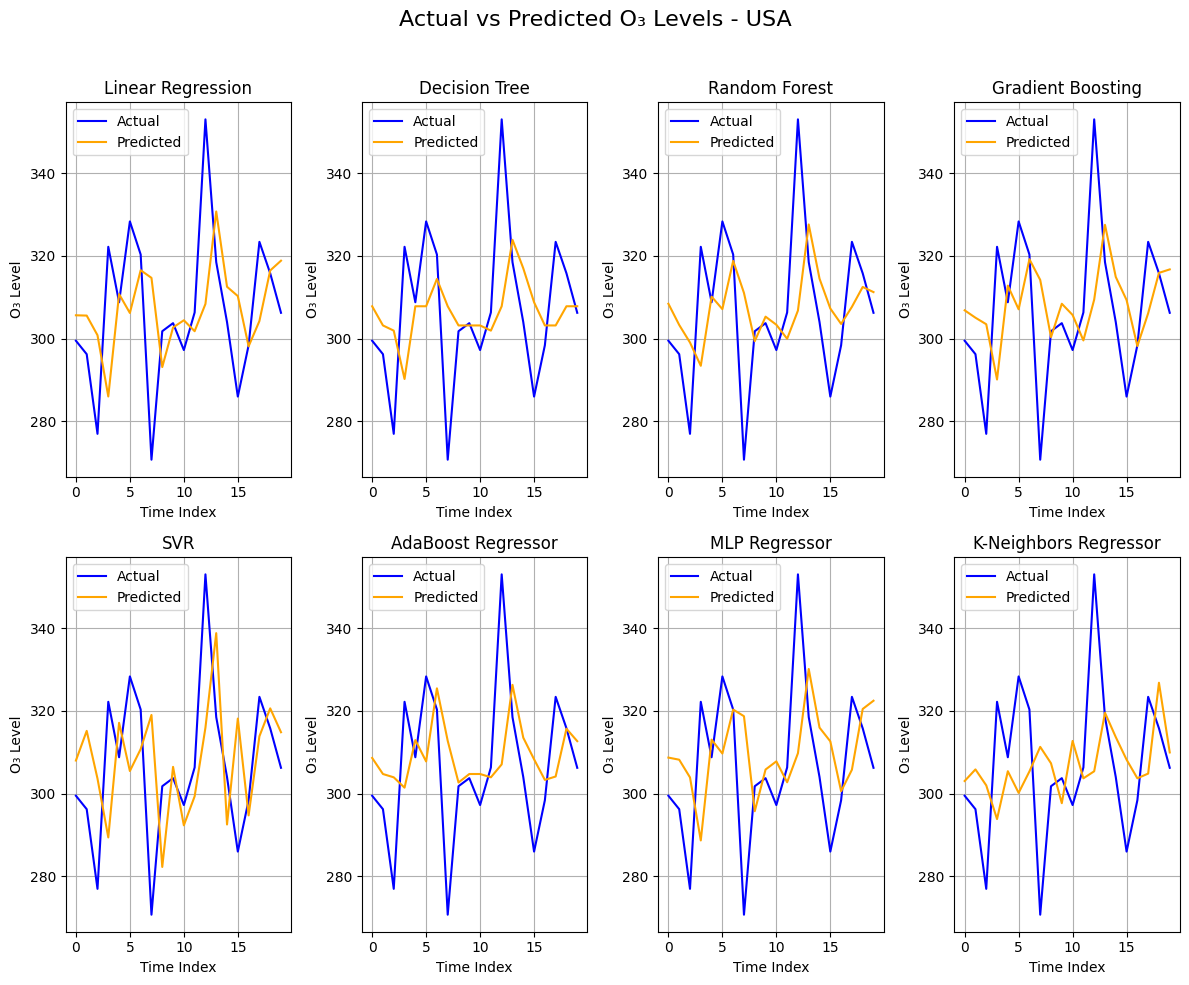

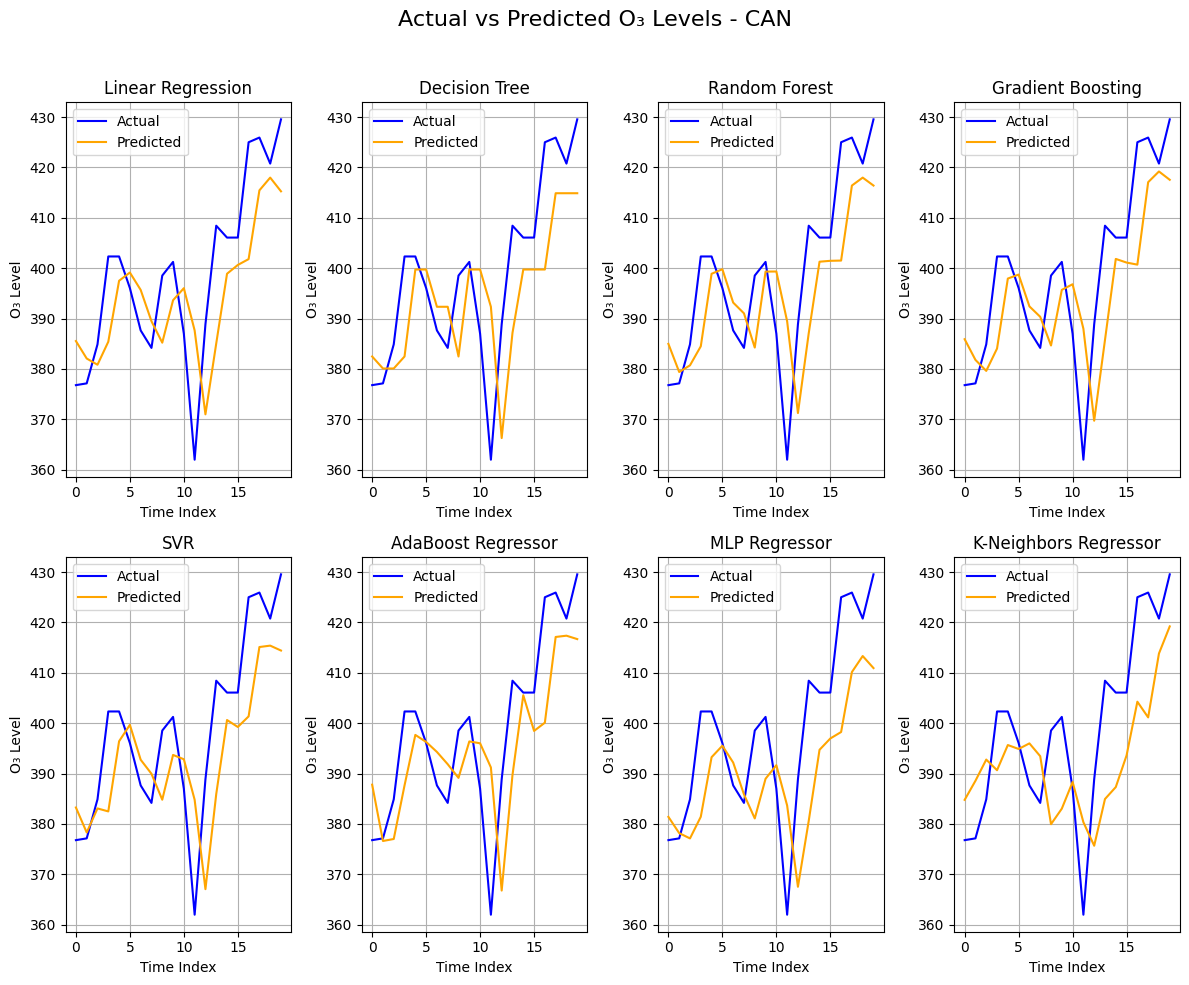

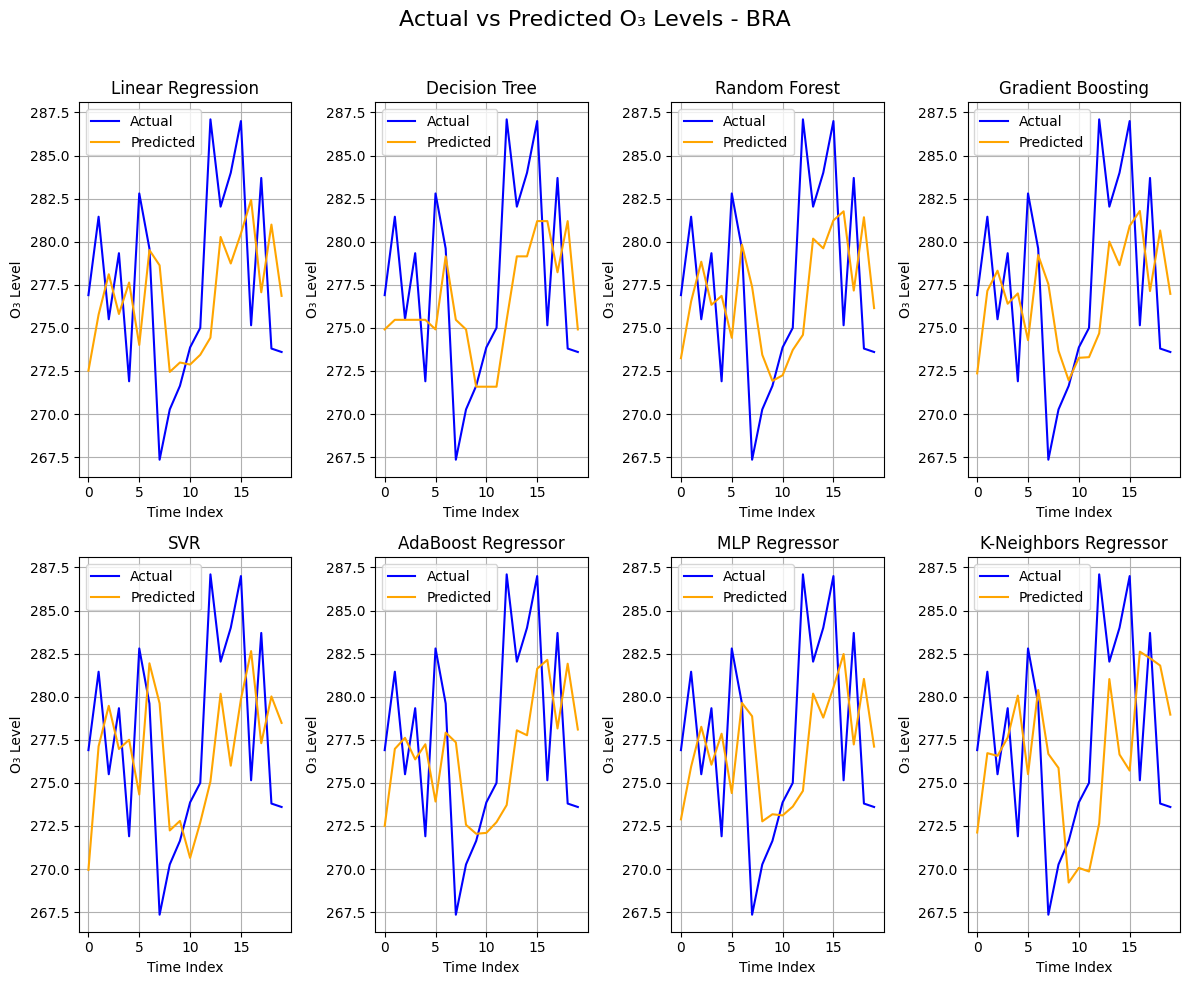

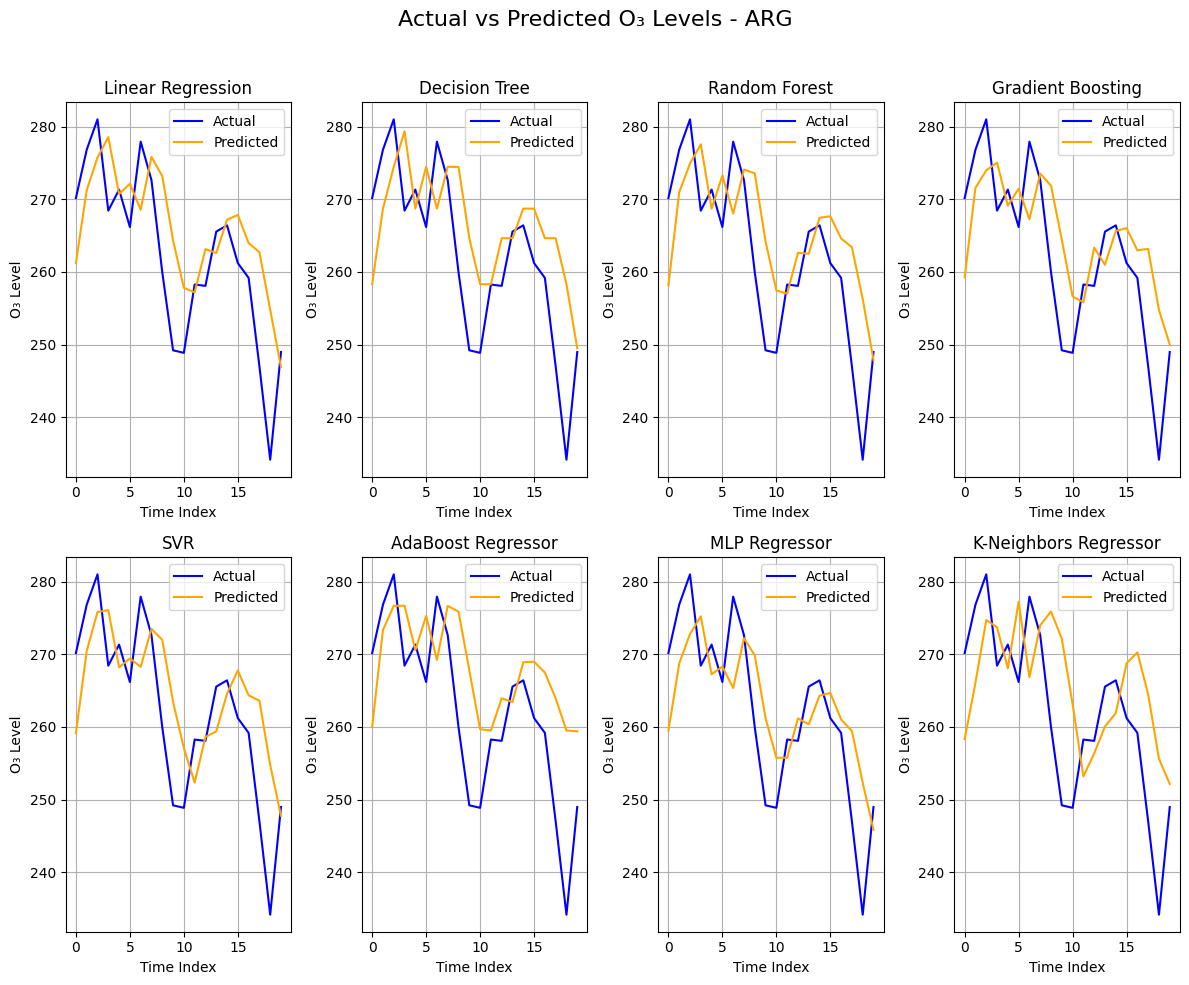

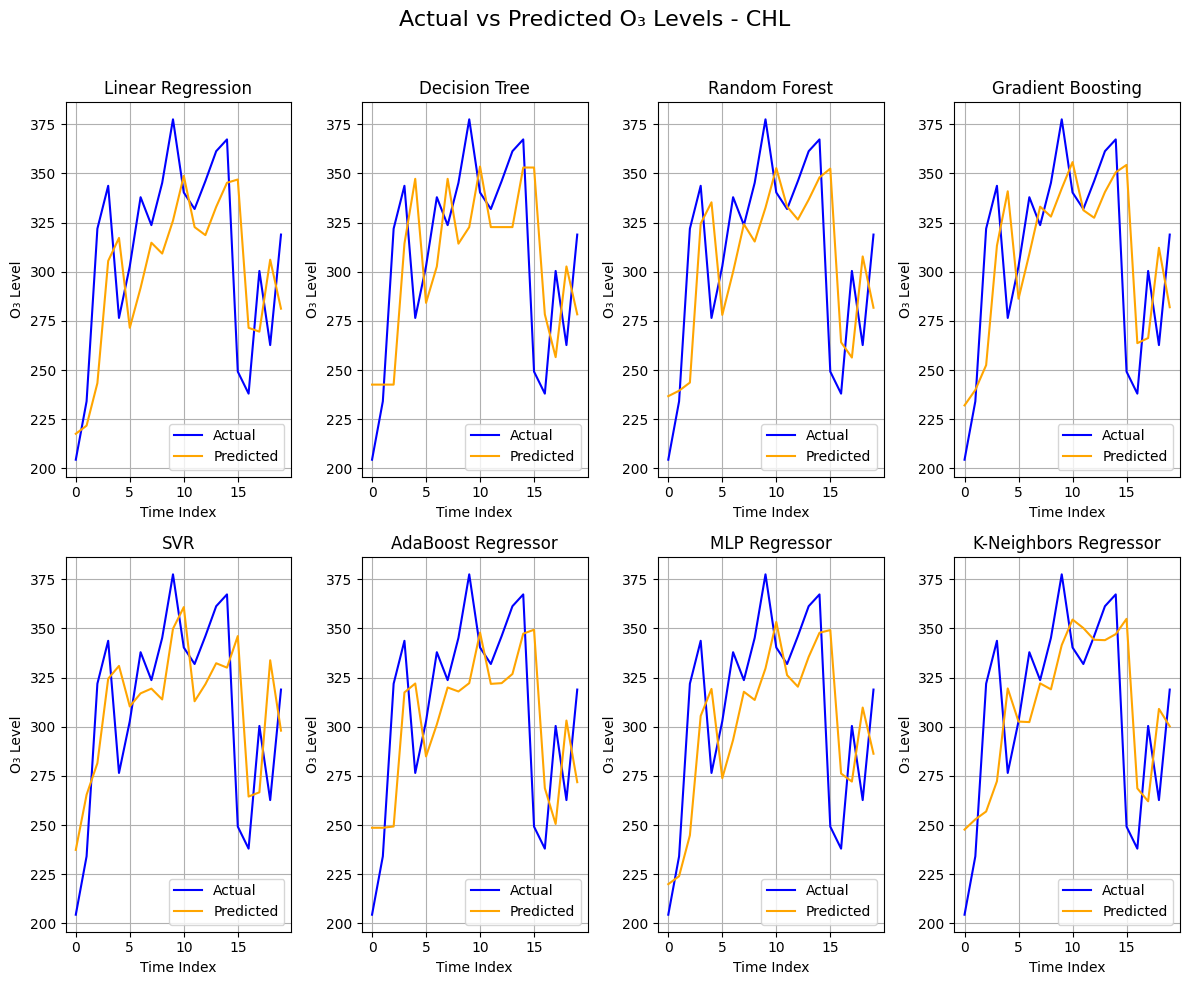

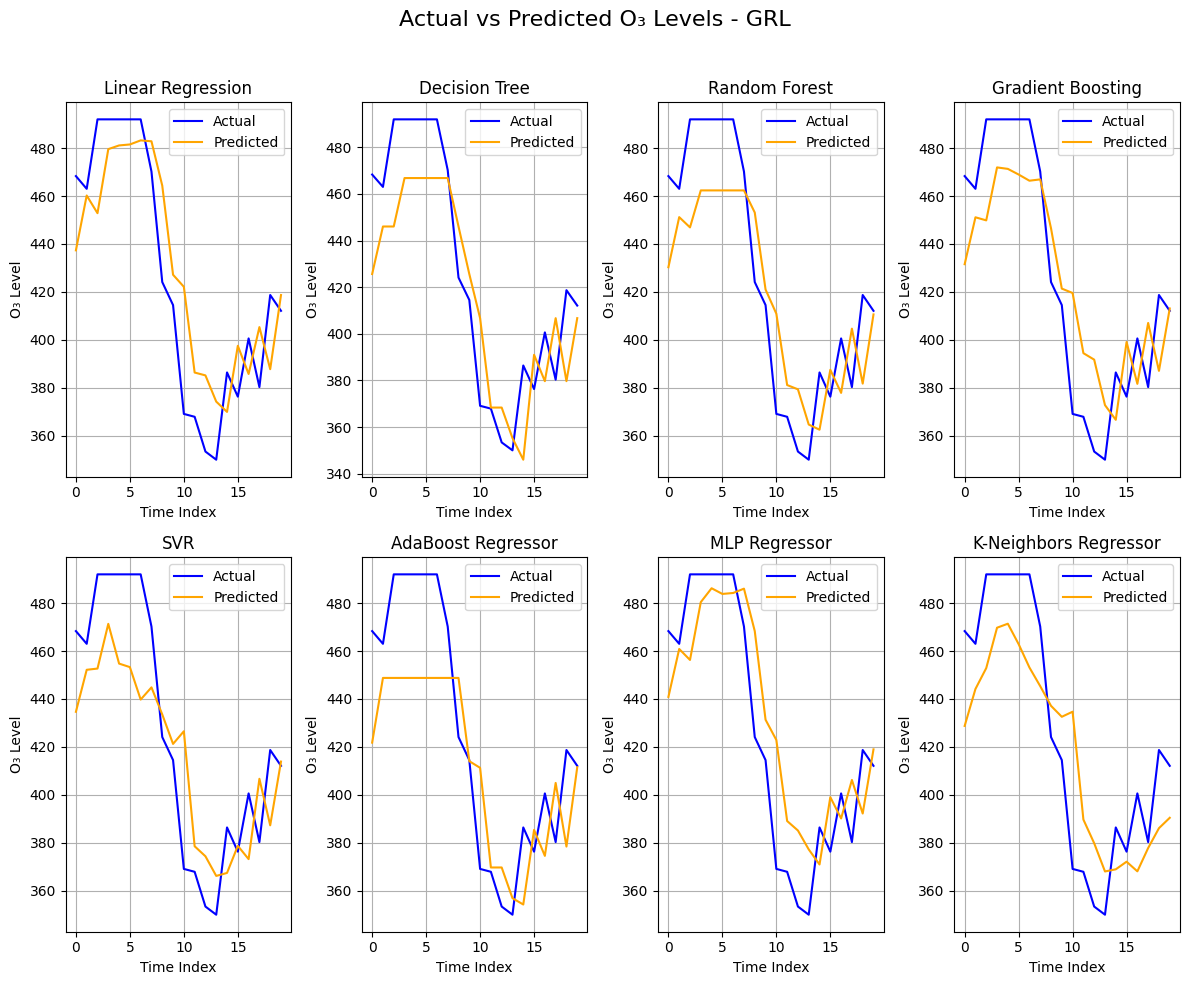

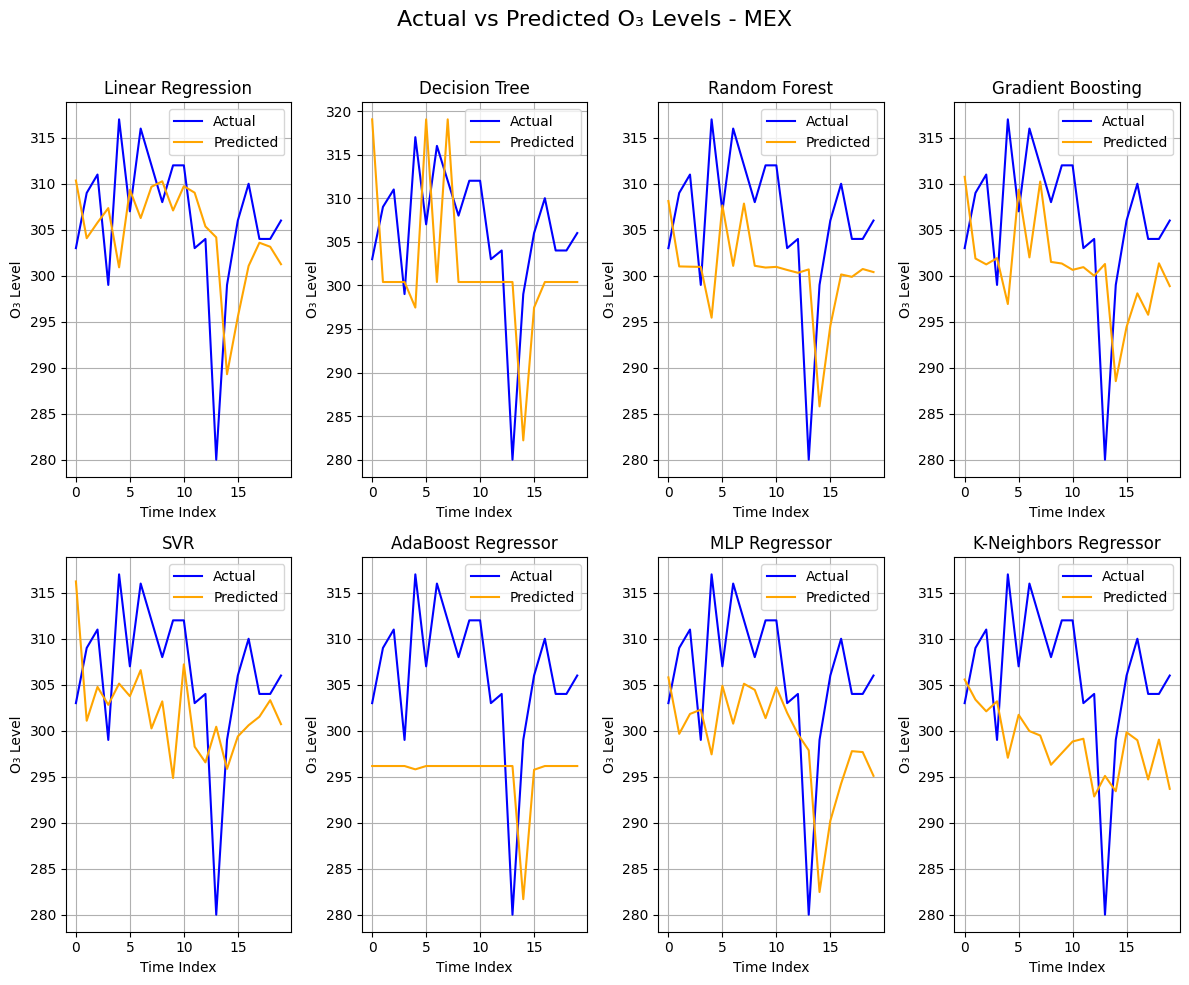

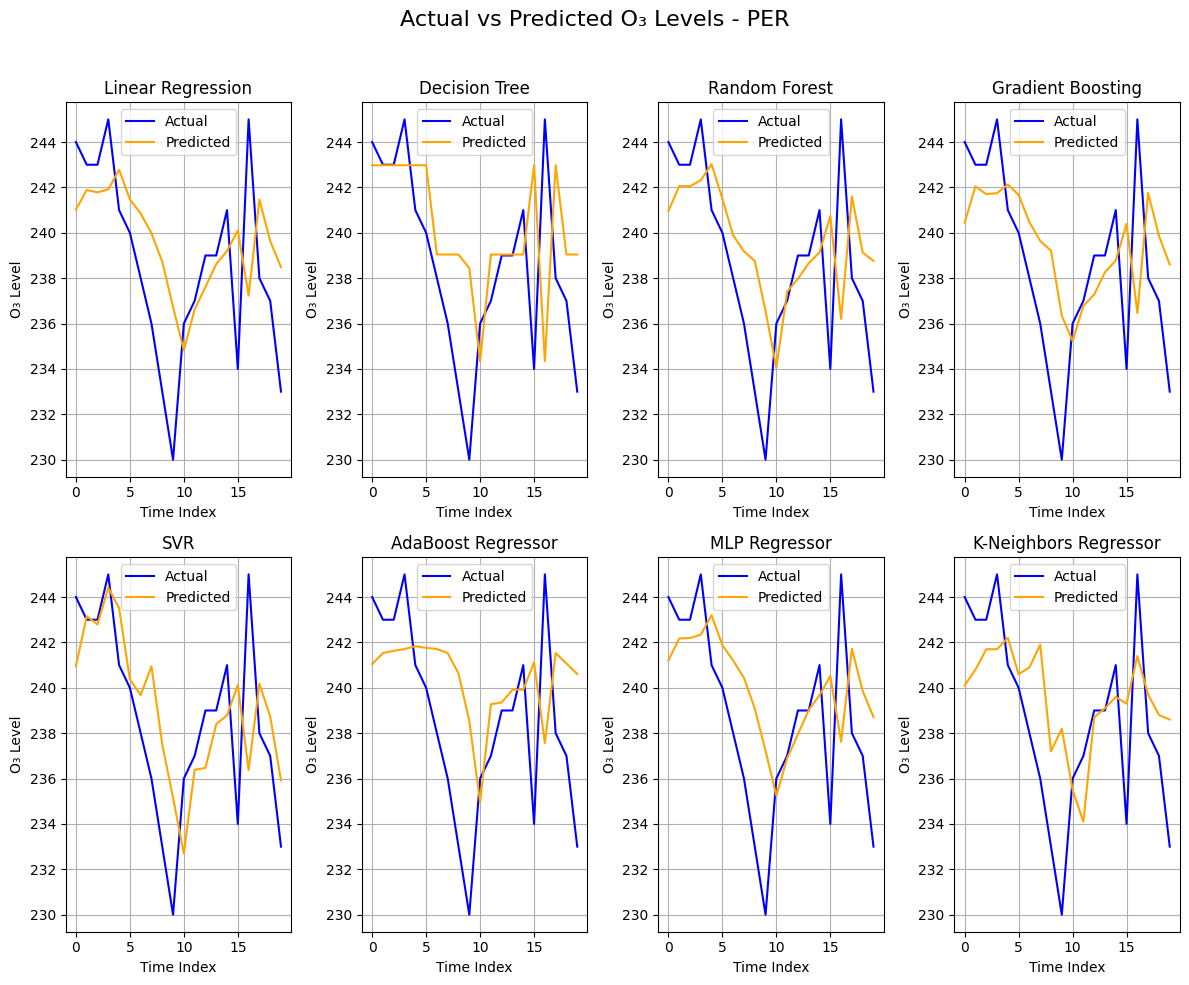

In [31]:
import matplotlib.pyplot as plt
import math

def plot_country_models_subplots(all_results, num_points=20):
    for country, models in all_results.items():
        num_models = len(models)
        cols = 4  # Adjust columns if needed
        rows = math.ceil(num_models / cols)

        fig, axs = plt.subplots(rows, cols, figsize=(12, 5 * rows))
        fig.suptitle(f"Actual vs Predicted O₃ Levels - {country}", fontsize=16)
        axs = axs.flatten()  # Flatten in case of 2D array

        for i, (model_name, res) in enumerate(models.items()):
            axs[i].plot(res['Actuals'][:num_points], label='Actual', color='blue')
            axs[i].plot(res['Predictions'][:num_points], label='Predicted', color='orange')
            axs[i].set_title(model_name)
            axs[i].set_xlabel('Time Index')
            axs[i].set_ylabel('O₃ Level')
            axs[i].grid(True)
            axs[i].legend()

        # Hide any unused subplots
        for j in range(i + 1, len(axs)):
            axs[j].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

# Example call:
plot_country_models_subplots(all_results)


<h1>Generic Combined Country Model Check</h1>

In [219]:
df=pd.concat([df1, df2, df3, df4, df5, df6, df7, df8], ignore_index=True)
df['daily_date'] = pd.to_datetime(df['daily_date'], format='%Y-%m-%d')
df.head()

,x,y,identifier,file_path,dataset_id,station_id,station_name,station_gaw_id,station_gaw_url,contributor_name,...,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,monthly_date,monthly_columno3,monthly_stdevo3,monthly_npts,url
0,-58.480,-34.580,Dobson:Beck:70:TotalOzone_1.0:091:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,91,Buenos Aires Observatorio,BSO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,6.0,1.800,NaN,2025-04-30T00:00:00Z,277.2,13.9,29.0,https://woudc.org/archive/Archive-NewFormat/To...
1,-68.310,-54.850,Dobson:Beck:131:TotalOzone_1.0:339:SMNA:WOUDC:...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,339,Ushuaia,USH,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,17.5,17.5,1.0,2.976,NaN,2025-04-30T00:00:00Z,277.0,27.7,30.0,https://woudc.org/archive/Archive-NewFormat/To...
2,-67.500,-45.783,Dobson:Beck:133:TotalOzone_1.0:342:SMNA:WOUDC:...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,342,Comodoro Rivadavia Aero,CMR,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,16.0,NaN,8.0,2.300,NaN,2025-04-30T00:00:00Z,263.4,21.7,28.0,https://woudc.org/archive/Archive-NewFormat/To...
3,-65.438,-22.111,Dobson:Beck:97:TotalOzone_1.0:513:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,513,La Quiaca,LQO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,3.0,1.500,NaN,2025-04-30T00:00:00Z,254.1,3.5,25.0,https://woudc.org/archive/Archive-NewFormat/To...
4,-58.480,-34.580,Dobson:Beck:70:TotalOzone_1.0:091:SMNA:WOUDC:2...,/apps/data/wdr-ingest/Archive-NewFormat/TotalO...,TotalOzone_1.0,91,Buenos Aires Observatorio,BSO,https://gawsis.meteoswiss.ch/GAWSIS/index.html...,National Meteorological Service of Argentina,...,15.0,NaN,6.0,1.700,NaN,2025-04-30T00:00:00Z,277.2,13.9,29.0,https://woudc.org/archive/Archive-NewFormat/To...


**Pre-Processing**

*Checking Null Values*

In [220]:
#finding missing value
print('Missing Value:')
print(df.isnull().sum())
print('***'*10)
#finding percantage of missing value
print('Percentage of Missing Value:')
print(df.isnull().sum()/df.shape[0]*100)
print('***'*10)
#finding duplicates
print('Duplicates:')
print(df.duplicated().sum())
print('***'*10)
#idenfying garbage value
print('Garbage Value:')
for i in df.select_dtypes(include='object').columns: #cz garbage are in object type value
   print(df[i].value_counts())
   print('***'*10)
# no garbage value as it would show in the last and show the character and the count also


Missing Value:
x                         0
y                         0
identifier                0
file_path                 0
dataset_id                0
station_id                0
station_name              0
station_gaw_id         1698
station_gaw_url           0
contributor_name          0
contributor_id            0
contributor_url       20833
country_id                0
country_name_en           0
country_name_fr           0
gaw_id               437135
instrument_name           0
instrument_model          0
instrument_serial         0
observation_date          0
daily_date                0
daily_wlcode           6829
daily_obscode             1
daily_columno3            0
daily_stdevo3        223703
daily_utc_begin      277790
daily_utc_end        277760
daily_utc_mean        39540
daily_nobs           224168
daily_mmu            252080
daily_columnso2      281795
monthly_date           8832
monthly_columno3       8832
monthly_stdevo3        8837
monthly_npts           8859
url  

**Droping Other Unnecessary Columns**

In [221]:
columns = [
    'x',
    'y',
    'identifier',
    'file_path',
    'dataset_id',
    'station_id',
    'station_name',
    'station_gaw_id',
    'station_gaw_url',
    'contributor_name',
    'contributor_id',
    'contributor_url',
    'country_id',
    'country_name_en',
    'country_name_fr',
    'gaw_id',
    'instrument_name',
    'instrument_model',
    'instrument_serial',
    'observation_date',
    'daily_wlcode',
    'daily_obscode',
    'daily_stdevo3',
    'daily_utc_begin',
    'daily_utc_end',
    'daily_utc_mean',
    'daily_nobs',
    'daily_mmu',
    'daily_columnso2',
    'monthly_date',
    'monthly_columno3',
    'monthly_stdevo3',
    'monthly_npts',
    'url',
    # 'Year',
    # 'period',
]
df.drop(columns=columns, inplace=True)

df.head()

,daily_date,daily_columno3
0,2025-04-30 00:00:00+00:00,264.0
1,2025-04-30 00:00:00+00:00,327.0
2,2025-04-30 00:00:00+00:00,256.0
3,2025-04-30 00:00:00+00:00,255.0
4,2025-04-29 00:00:00+00:00,265.0


**Grouping Values with same date-time**

In [222]:
#finding missing value
print('Missing Value:')
print(df.isnull().sum())
print('***'*10)
#finding percantage of missing value
print('Percentage of Missing Value:')
print(df.isnull().sum()/df.shape[0]*100)
print('***'*10)
#finding duplicates
print('Duplicates:')
print(df.duplicated().sum())
print('***'*10)
#idenfying garbage value
print('Garbage Value:')
for i in df.select_dtypes(include='object').columns: #cz garbage are in object type value
   print(df[i].value_counts())
   print('***'*10)
# no garbage value as it would show in the last and show the character and the count also


Missing Value:
daily_date        0
daily_columno3    0
dtype: int64
******************************
Percentage of Missing Value:
daily_date        0.0
daily_columno3    0.0
dtype: float64
******************************
Duplicates:
10879
******************************
Garbage Value:


In [223]:
df = df.groupby('daily_date').mean(numeric_only=True).reset_index()
df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)
df.dropna(subset=['daily_columno3'], inplace=True)

df.head()

,daily_date,daily_columno3
0,1957-07-01 00:00:00+00:00,337.766667
1,1957-07-02 00:00:00+00:00,303.966667
2,1957-07-03 00:00:00+00:00,322.500000
3,1957-07-04 00:00:00+00:00,322.500000
4,1957-07-05 00:00:00+00:00,317.966667


In [224]:
print(F"Shape after dropping NaN values: {df.shape}")

Shape after dropping NaN values: (24745, 2)


**Checking For Outliers**

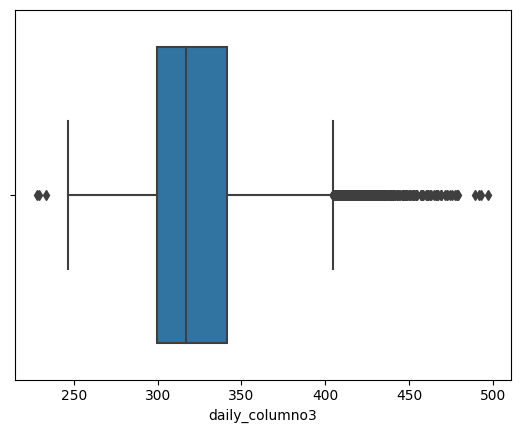

In [225]:
for i in ["daily_columno3"]:
  sns.boxplot(data=df,x=i)
  plt.show()

**Calculating Wiskers to treat outliers**

In [226]:
#Outlier treatment
def wisker(col):
  q1,q3=np.percentile(col,[25,75])
  iqr=q3-q1
  lower_bound=q1-(1.5*iqr)
  upper_bound=q3+(1.5*iqr)
  return lower_bound,upper_bound
df.columns

Index(['daily_date', 'daily_columno3'], dtype='object')

**Treating Outliers**

In [227]:
for i in ["daily_columno3"]:
  lw,uk=wisker(df[i])
  df[i]=np.where(df[i]>uk,uk,df[i])
  df[i]=np.where(df[i]<lw,lw,df[i])

**Checking If outliers Remains**

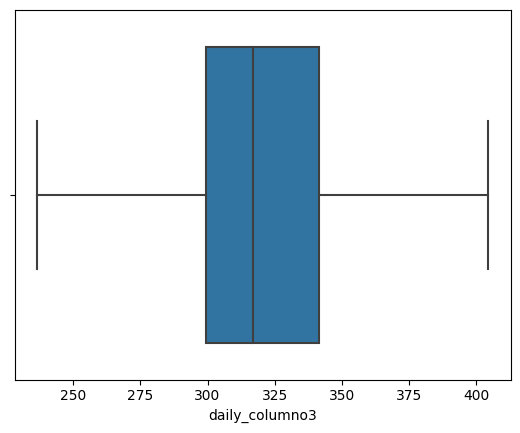

In [228]:
for i in ["daily_columno3"]:
  sns.boxplot(data=df,x=i)
  plt.show()

**Creating Lag features**

In [229]:
df['rolling_avg'] = df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
df['rolling_std'] = df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
df['ewm_avg'] = df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
df['ewm_std'] = df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 16):
  df[f'lag{i}'] = df['daily_columno3'].shift(i)

df.dropna(inplace=True)
print(df.shape)
df.head()

(24730, 21)


,daily_date,daily_columno3,rolling_avg,rolling_std,ewm_avg,ewm_std,lag1,lag2,lag3,lag4,...,lag6,lag7,lag8,lag9,lag10,lag11,lag12,lag13,lag14,lag15
15,1957-07-16 00:00:00+00:00,335.94,330.374167,5.969687,328.764897,6.688511,329.88,322.45,330.525,327.400,...,335.180,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000,303.966667,337.766667
16,1957-07-17 00:00:00+00:00,328.16,331.261500,6.081848,330.124281,6.711755,335.94,329.88,322.450,330.525,...,339.640,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000,303.966667
17,1957-07-18 00:00:00+00:00,318.60,330.097500,5.334002,329.754953,6.096926,328.16,335.94,329.880,322.450,...,327.400,339.640000,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000,322.500000
18,1957-07-19 00:00:00+00:00,315.88,329.384167,6.360663,327.670509,7.163891,318.60,328.16,335.940,329.880,...,330.525,327.400000,339.640000,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667,322.500000
19,1957-07-20 00:00:00+00:00,310.10,328.365500,7.638370,325.478361,8.076394,315.88,318.60,328.160,335.940,...,322.450,330.525000,327.400000,339.640000,335.180000,326.066667,325.733333,339.800000,327.066667,317.966667


**Spliting and scalling data**

In [230]:
lag_features = [f'lag{i}' for i in range(1, 16)]
lag_features.append('rolling_avg')
lag_features.append('rolling_std')
lag_features.append('ewm_avg')
lag_features.append('ewm_std')
X= df[lag_features]
y = df['daily_columno3']

minmax_x = MinMaxScaler()
minmax_y = MinMaxScaler()
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# Scale the features
X_train= minmax_x.fit_transform(X_train)
X_test= minmax_x.transform(X_test)
# Scale the target variable
y_train= minmax_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test= minmax_y.transform(y_test.values.reshape(-1, 1)).flatten()

**Training Models**

In [231]:


# STEP 3: Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Support Vector Regressor': SVR(),
    'AdaBoost Regressor': AdaBoostRegressor(n_estimators=50, random_state=42),
    'MLP Regressor': MLPRegressor(hidden_layer_sizes=(50,), max_iter=500, random_state=42),
    'K-Neighbors Regressor': KNeighborsRegressor(n_neighbors=3)
}

# STEP 4: Train, Predict, and Evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {
        'Model': model,
        'Predictions': preds,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# STEP 5: Print evaluation metrics
print("Model Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2']*100):.2f} %\n")

# STEP 6: Plot actual vs predicted

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.056
MAE : 0.041
R2  : 87.36 %

----- Decision Tree -----
RMSE: 0.079
MAE : 0.059
R2  : 74.42 %

----- Random Forest -----
RMSE: 0.057
MAE : 0.042
R2  : 86.73 %

----- Gradient Boosting -----
RMSE: 0.056
MAE : 0.041
R2  : 87.15 %

----- Support Vector Regressor -----
RMSE: 0.058
MAE : 0.043
R2  : 86.15 %

----- AdaBoost Regressor -----
RMSE: 0.065
MAE : 0.050
R2  : 82.88 %

----- MLP Regressor -----
RMSE: 0.056
MAE : 0.041
R2  : 87.16 %

----- K-Neighbors Regressor -----
RMSE: 0.066
MAE : 0.049
R2  : 82.22 %



**HyperParameter Tuning**

In [232]:

param_spaces = {
    'Linear Regression': {},
    'Decision Tree': {
        'max_depth': ('int', 3, 10),
        'min_samples_split': ('int', 2, 10),
    },
    'Random Forest': {
        'n_estimators': ('int', 50, 200),
        'max_depth': ('int', 3, 10),
    },
    'Gradient Boosting': {
        'n_estimators': ('int', 50, 200),
        'learning_rate': ('float', 0.01, 0.3),
        'max_depth': ('int', 3, 7),
    },
    'SVR': {
        'C': ('float', 0.1, 10),
        'epsilon': ('float', 0.01, 1.0),
    },
    'AdaBoost Regressor': {
        'n_estimators': ('int', 50, 150),
        'learning_rate': ('float', 0.01, 1.0),
    },
    'MLP Regressor': {
        'hidden_layer_sizes': ('cat', [(50,), (100,), (50, 50)]),
        'alpha': ('float', 0.0001, 0.01),
        'learning_rate_init': ('float', 0.001, 0.05),
    },
    'K-Neighbors Regressor': {
        'n_neighbors': ('int', 2, 10),
    }
}

# ----------- STEP 4: Models Dictionary ----------- #
model_classes = {
    'Linear Regression': LinearRegression,
    'Decision Tree': DecisionTreeRegressor,
    'Random Forest': RandomForestRegressor,
    'Gradient Boosting': GradientBoostingRegressor,
    'SVR': SVR,
    'AdaBoost Regressor': AdaBoostRegressor,
    'MLP Regressor': MLPRegressor,
    'K-Neighbors Regressor': KNeighborsRegressor,
}

# ----------- STEP 5: Suggestion Utility ----------- #
def suggest(trial, name, dist):
    if isinstance(dist, tuple) and dist[0] == 'int':
        return trial.suggest_int(name, *dist[1:])
    elif isinstance(dist, tuple) and dist[0] == 'float':
        return trial.suggest_float(name, *dist[1:])
    elif isinstance(dist, tuple) and dist[0] == 'cat':
        return trial.suggest_categorical(name, dist[1])
    else:
        raise ValueError(f"Unsupported distribution type for {name}: {dist}")

# ----------- STEP 6: Model Tuning Function ----------- #
def tune_model(name, model_class, param_space, n_trials=10):
    if not param_space:
        return model_class()

    def objective(trial):
        params = {key: suggest(trial, key, dist) for key, dist in param_space.items()}
        model = model_class(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = mean_squared_error(y_test, preds)
        return rmse

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials)
    print(f"{name} Best Params: {study.best_params}")
    return model_class(**study.best_params)

# ----------- STEP 7: Tuning and Evaluation ----------- #
results = {}
best_models = {}

for name in model_classes:
    print(f"\nTuning {name}...")
    model = tune_model(name, model_classes[name], param_spaces.get(name, {}), n_trials=20)
    model.fit(X_train, y_train)
    best_models[name] = model

    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {
        'Predictions': preds,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

# ----------- STEP 8: Print Metrics ----------- #
print("\nModel Evaluation Metrics:\n")
for name, res in results.items():
    print(f"----- {name} -----")
    print(f"RMSE: {res['RMSE']:.3f}")
    print(f"MAE : {res['MAE']:.3f}")
    print(f"R2  : {(res['R2'] * 100):.2f} %\n")



[I 2025-06-12 22:37:07,947] A new study created in memory with name: no-name-0a5a8d65-6ac2-40b0-bf0b-6fb9e316c15e



Tuning Linear Regression...

Tuning Decision Tree...


[I 2025-06-12 22:37:08,115] Trial 0 finished with value: 0.0033573491675819543 and parameters: {'max_depth': 5, 'min_samples_split': 10}. Best is trial 0 with value: 0.0033573491675819543.
[I 2025-06-12 22:37:08,325] Trial 1 finished with value: 0.003623448406503451 and parameters: {'max_depth': 8, 'min_samples_split': 7}. Best is trial 0 with value: 0.0033573491675819543.
[I 2025-06-12 22:37:08,435] Trial 2 finished with value: 0.0035562036519735277 and parameters: {'max_depth': 4, 'min_samples_split': 3}. Best is trial 0 with value: 0.0033573491675819543.
[I 2025-06-12 22:37:08,506] Trial 3 finished with value: 0.00409880312648952 and parameters: {'max_depth': 3, 'min_samples_split': 9}. Best is trial 0 with value: 0.0033573491675819543.
[I 2025-06-12 22:37:08,688] Trial 4 finished with value: 0.0034479251692344872 and parameters: {'max_depth': 7, 'min_samples_split': 8}. Best is trial 0 with value: 0.0033573491675819543.
[I 2025-06-12 22:37:08,767] Trial 5 finished with value: 0.004

Decision Tree Best Params: {'max_depth': 6, 'min_samples_split': 2}

Tuning Random Forest...


[I 2025-06-12 22:37:26,904] Trial 0 finished with value: 0.0031429261449222087 and parameters: {'n_estimators': 106, 'max_depth': 10}. Best is trial 0 with value: 0.0031429261449222087.
[I 2025-06-12 22:37:45,692] Trial 1 finished with value: 0.003096204821694166 and parameters: {'n_estimators': 160, 'max_depth': 7}. Best is trial 1 with value: 0.003096204821694166.
[I 2025-06-12 22:37:50,572] Trial 2 finished with value: 0.003309189784720651 and parameters: {'n_estimators': 73, 'max_depth': 4}. Best is trial 1 with value: 0.003096204821694166.
[I 2025-06-12 22:37:58,114] Trial 3 finished with value: 0.003118683235033053 and parameters: {'n_estimators': 58, 'max_depth': 9}. Best is trial 1 with value: 0.003096204821694166.
[I 2025-06-12 22:38:14,600] Trial 4 finished with value: 0.0031159398020891996 and parameters: {'n_estimators': 140, 'max_depth': 8}. Best is trial 1 with value: 0.003096204821694166.
[I 2025-06-12 22:38:22,127] Trial 5 finished with value: 0.003157428576557875 and p

...

MLP Regressor Best Params: {'hidden_layer_sizes': (100,), 'alpha': 0.001794918594928324, 'learning_rate_init': 0.02864787614752198}


[I 2025-06-12 22:53:40,744] A new study created in memory with name: no-name-20eceb3e-46a8-4cfd-8a55-f8bc5c5b7742



Tuning K-Neighbors Regressor...


[I 2025-06-12 22:53:42,294] Trial 0 finished with value: 0.00394734511697004 and parameters: {'n_neighbors': 5}. Best is trial 0 with value: 0.00394734511697004.
[I 2025-06-12 22:53:43,707] Trial 1 finished with value: 0.0037016153363662475 and parameters: {'n_neighbors': 10}. Best is trial 1 with value: 0.0037016153363662475.
[I 2025-06-12 22:53:45,090] Trial 2 finished with value: 0.0037726162065070384 and parameters: {'n_neighbors': 8}. Best is trial 1 with value: 0.0037016153363662475.
[I 2025-06-12 22:53:46,554] Trial 3 finished with value: 0.0038140498921089955 and parameters: {'n_neighbors': 7}. Best is trial 1 with value: 0.0037016153363662475.
[I 2025-06-12 22:53:47,935] Trial 4 finished with value: 0.004337274914625838 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.0037016153363662475.
[I 2025-06-12 22:53:49,335] Trial 5 finished with value: 0.004337274914625838 and parameters: {'n_neighbors': 3}. Best is trial 1 with value: 0.0037016153363662475.
[I 2025-0

K-Neighbors Regressor Best Params: {'n_neighbors': 10}

Model Evaluation Metrics:

----- Linear Regression -----
RMSE: 0.056
MAE : 0.041
R2  : 87.36 %

----- Decision Tree -----
RMSE: 0.058
MAE : 0.043
R2  : 86.26 %

----- Random Forest -----
RMSE: 0.056
MAE : 0.041
R2  : 87.28 %

----- Gradient Boosting -----
RMSE: 0.056
MAE : 0.041
R2  : 87.30 %

----- SVR -----
RMSE: 0.058
MAE : 0.043
R2  : 85.98 %

----- AdaBoost Regressor -----
RMSE: 0.059
MAE : 0.044
R2  : 85.62 %

----- MLP Regressor -----
RMSE: 0.057
MAE : 0.043
R2  : 86.65 %

----- K-Neighbors Regressor -----
RMSE: 0.061
MAE : 0.045
R2  : 84.83 %



**Predicted value vs Actual value**

In [233]:
# Number of rows to display
n_display = 10

print("\n--- Actual vs Predicted on Test Set (Top 10 Rows) ---\n")
for name, res in results.items():
    print(f"--- {name} ---")
    comparison = pd.DataFrame({
        'Actual': y_test[:n_display],
        'Predicted': res['Predictions'][:n_display]

    })
    print(comparison.round(3))
    print("\n")



--- Actual vs Predicted on Test Set (Top 10 Rows) ---

--- Linear Regression ---
   Actual  Predicted
0   0.296      0.273
1   0.322      0.290
2   0.331      0.312
3   0.280      0.322
4   0.284      0.289
5   0.306      0.293
6   0.296      0.304
7   0.268      0.296
8   0.250      0.280
9   0.184      0.264


--- Decision Tree ---
   Actual  Predicted
0   0.296      0.286
1   0.322      0.306
2   0.331      0.322
3   0.280      0.322
4   0.284      0.286
5   0.306      0.286
6   0.296      0.306
7   0.268      0.306
8   0.250      0.286
9   0.184      0.264


--- Random Forest ---
   Actual  Predicted
0   0.296      0.282
1   0.322      0.299
2   0.331      0.317
3   0.280      0.326
4   0.284      0.285
5   0.306      0.288
6   0.296      0.311
7   0.268      0.299
8   0.250      0.282
9   0.184      0.261


--- Gradient Boosting ---
   Actual  Predicted
0   0.296      0.282
1   0.322      0.298
2   0.331      0.315
3   0.280      0.319
4   0.284      0.286
5   0.306      0.289
6 

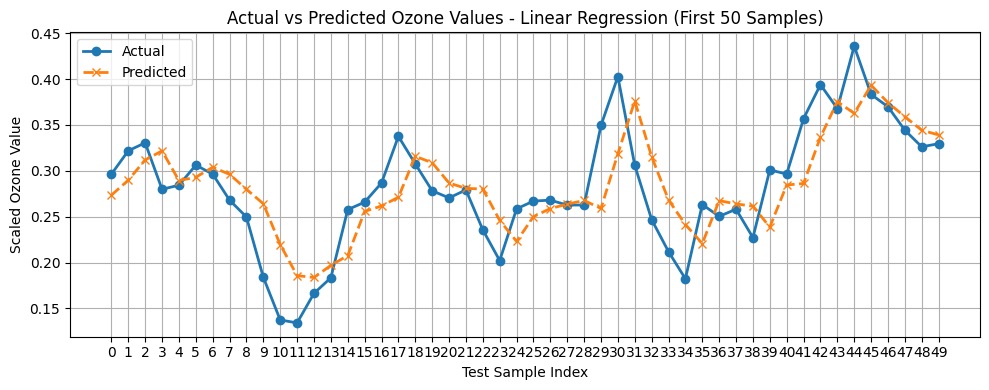

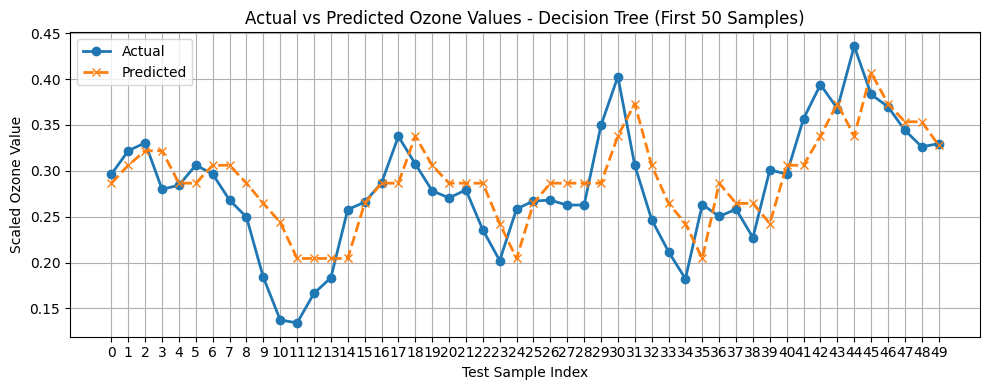

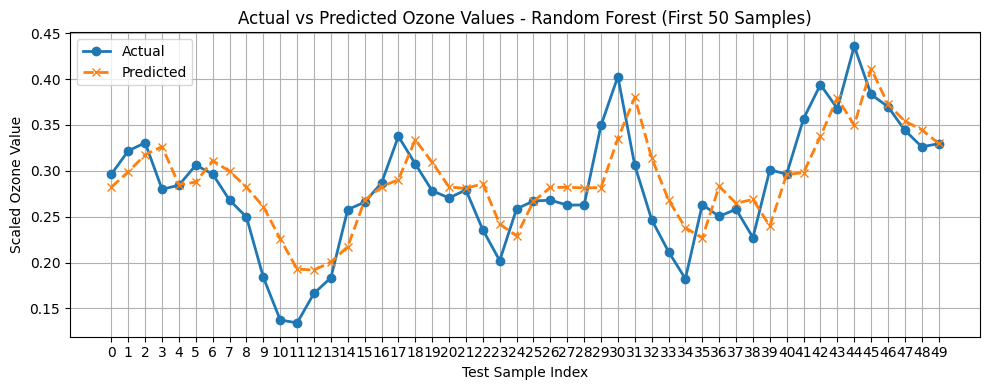

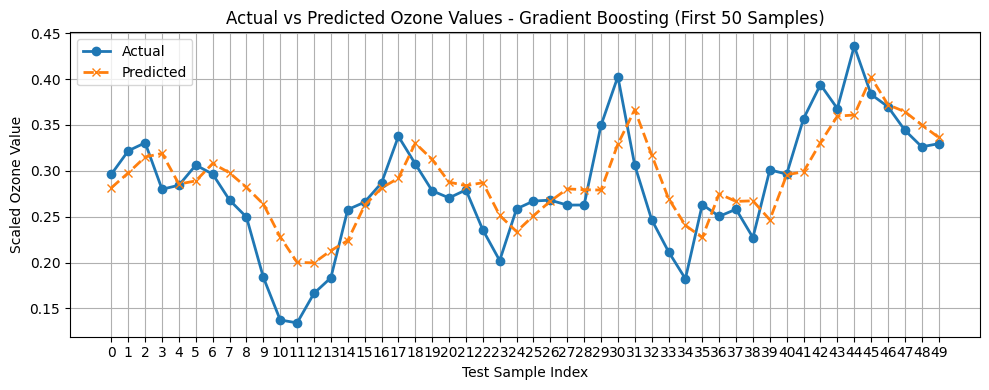

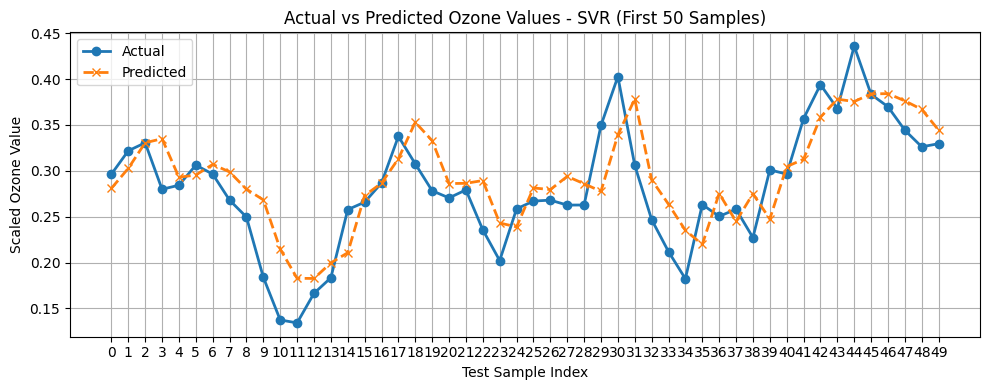

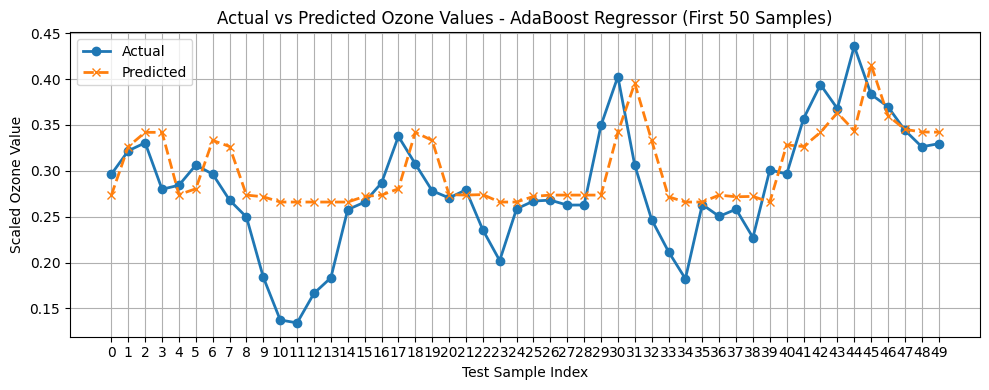

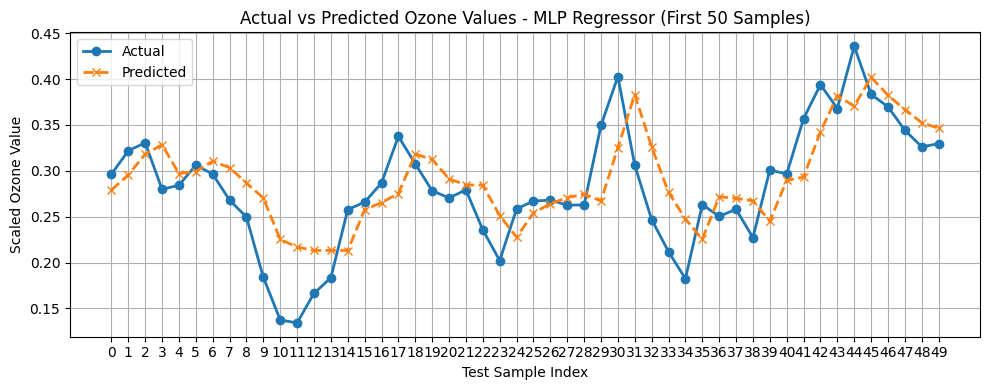

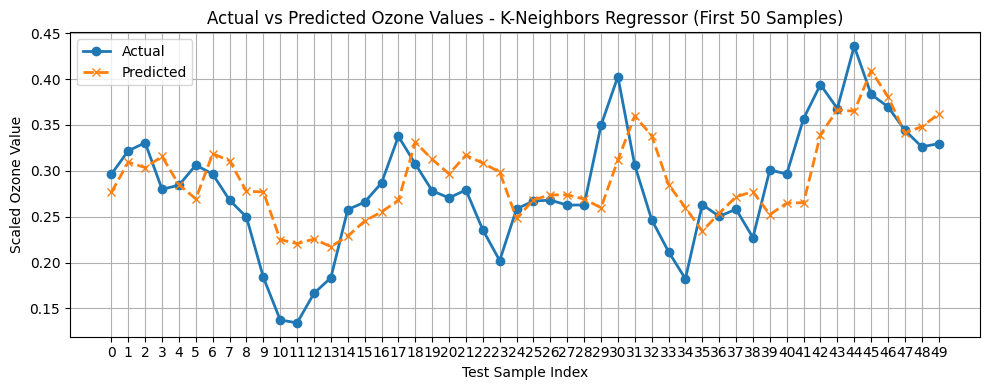

In [234]:
n_display = 50  # Only show the first 10 test samples

for name, res in results.items():
    plt.figure(figsize=(10, 4))
    plt.plot(range(n_display), y_test[:n_display], label='Actual', linewidth=2, marker='o')
    plt.plot(range(n_display), res['Predictions'][:n_display], label='Predicted', linewidth=2, linestyle='--', marker='x')
    
    plt.title(f'Actual vs Predicted Ozone Values - {name} (First {n_display} Samples)')
    plt.xlabel('Test Sample Index')
    plt.ylabel('Scaled Ozone Value')
    plt.xticks(range(n_display))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


**Performace Comparison**

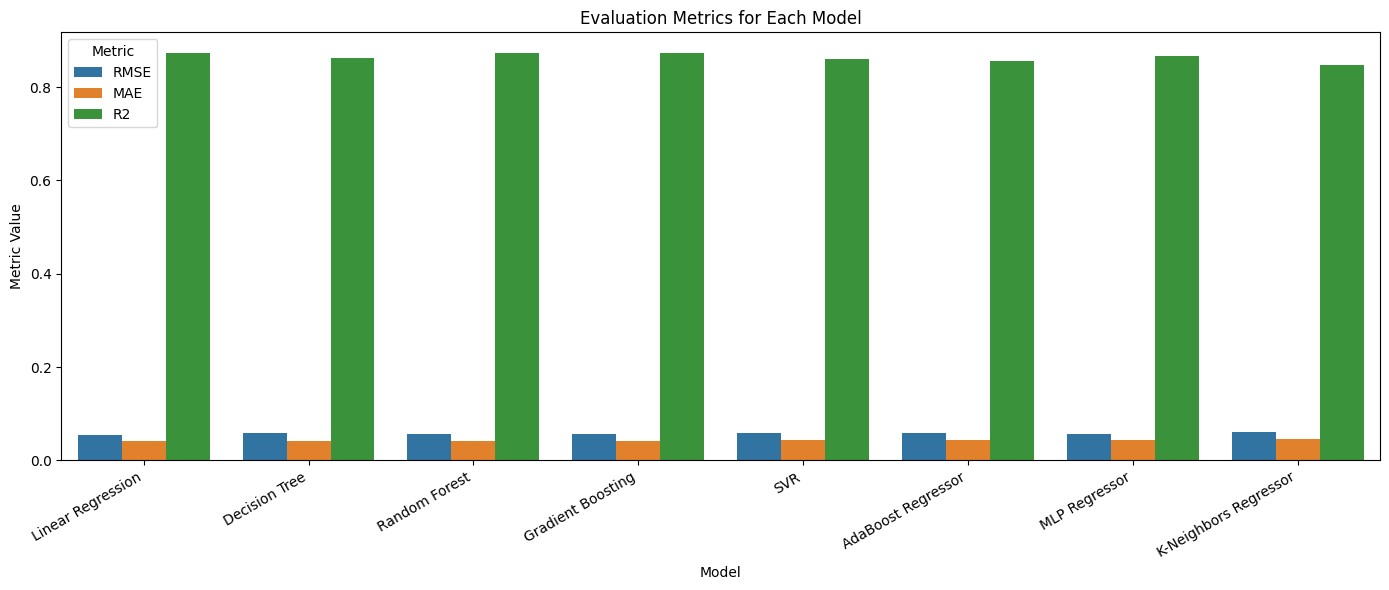

In [235]:
# Prepare data for bar chart
metrics_df = pd.DataFrame({
    'Model': list(results.keys()),
    'RMSE': [res['RMSE'] for res in results.values()],
    'MAE': [res['MAE'] for res in results.values()],
    'R2': [res['R2'] for res in results.values()]
})

plt.figure(figsize=(14, 6))
metrics_df_melted = metrics_df.melt(id_vars='Model', value_vars=['RMSE', 'MAE', 'R2'], var_name='Metric', value_name='Value')
sns.barplot(data=metrics_df_melted, x='Model', y='Value', hue='Metric')
plt.title('Evaluation Metrics for Each Model')
plt.ylabel('Metric Value')
plt.xlabel('Model')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()